# EDA - ClinVar conflicting classifications

**Subject and product concept.** ClinVar is NCBI's public archive of human genetic variants and their clinical significance, as submitted by diagnostic labs and researchers. When two or more labs classify the same variant differently (for example "benign" vs. "pathogenic"), the variant has *conflicting interpretations*, which undermines its use in clinical reporting and triggers manual curation.

**Goal.** Predict, from the variant's genomic and functional annotation, whether a variant is likely to receive conflicting classifications. The prediction can be used to prioritize variants for expert review or to flag low-confidence reports.

**Target.** `CLASS`, binary: 1 = conflicting classifications, 0 = consistent classifications.

**Unit of observation.** One row is one variant, keyed by `CHROM`, `POS`, `REF`, `ALT` (equivalently the HGVS string `CLNHGVS`). Variants are grouped by gene (`SYMBOL`), which repeats across rows.

**Timeline.** No timestamps. Annotations (allele frequencies, VEP consequence, CADD, SIFT, PolyPhen) are known before classification; ClinVar-derived fields (`CLNDN`, `CLNDISDB`, `CLNVI`, `CLNSIGINCL`) come from the submissions themselves and are checked for leakage in Section 11.

**Dataset description.** No data dictionary is shipped with the Kaggle download (`kevinarvai/clinvar-conflicting`). Column meanings are taken from the ClinVar VCF INFO fields and Ensembl VEP output conventions; anything beyond that is marked as inferred.

In [1]:
import os
import difflib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60, "display.width", 200)

SEED = 42
FIG = Path("figures")
FIG.mkdir(exist_ok=True)


def save(name):
    plt.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()


print("setup done, figures ->", FIG.resolve())

setup done, figures -> C:\Users\Or\OneDrive\Desktop\repos\Learnings\ClinVar\figures


## 0. Load data
Raw data stays in `df_raw`; every change to the analysis frame `df` is recorded in `cleaning_log`.

In [2]:
import kagglehub

# Load KAGGLE_API_TOKEN from the repo-root .env
for line in (Path.cwd().parent / ".env").read_text().splitlines():
    key, _, value = line.strip().partition("=")
    if key and not key.startswith("#"):
        os.environ.setdefault(key, value.strip().strip("\"'"))

path = kagglehub.dataset_download("kevinarvai/clinvar-conflicting")
print(path, os.listdir(path))

C:\Users\Or\.cache\kagglehub\datasets\kevinarvai\clinvar-conflicting\versions\2 ['clinvar_conflicting.csv']


In [3]:
df_raw = pd.read_csv(Path(path) / "clinvar_conflicting.csv", low_memory=False)
df = df_raw.copy()

cleaning_log = []


def log(step, detail, n):
    cleaning_log.append({"step": step, "detail": detail, "rows_affected": int(n)})


print(f"shape: {df_raw.shape}, memory: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("single file, no train/test split -> full data analyzed, split advice in Section 12")

shape: (65188, 46), memory: 132.1 MB
single file, no train/test split -> full data analyzed, split advice in Section 12


## 1. First look
Shape, types, parsing fixes, column classification, grain and repeated entities.

In [4]:
df_raw.head()

,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDISDB,CLNDISDBINCL,CLNDN,CLNDNINCL,CLNHGVS,CLNSIGINCL,CLNVC,CLNVI,MC,ORIGIN,SSR,CLASS,Allele,Consequence,IMPACT,SYMBOL,Feature_type,Feature,BIOTYPE,EXON,INTRON,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,DISTANCE,STRAND,BAM_EDIT,SIFT,PolyPhen,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,LoFtool,CADD_PHRED,CADD_RAW,BLOSUM62
0,1,1168180,G,C,0.0771,0.10020,0.1066,MedGen:CN169374,NaN,not_specified,NaN,NC_000001.10:g.1168180G>C,NaN,single_nucleotide_variant,UniProtKB_(protein):Q96L58#VAR_059317,SO:0001583|missense_variant,1,NaN,0,C,missense_variant,MODERATE,B3GALT6,Transcript,NM_080605.3,protein_coding,1/1,NaN,552,522,174,E/D,gaG/gaC,NaN,1.0,NaN,tolerated,benign,NaN,NaN,NaN,NaN,NaN,1.053,-0.208682,2.0
1,1,1470752,G,A,0.0000,0.00000,0.0000,"MedGen:C1843891,OMIM:607454,Orphanet:ORPHA9877...",NaN,Spinocerebellar_ataxia_21|not_provided,NaN,NC_000001.10:g.1470752G>A,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:616101.0001|UniProtKB_(pr...,SO:0001583|missense_variant,1,NaN,0,A,missense_variant,MODERATE,TMEM240,Transcript,NM_001114748.1,protein_coding,4/4,NaN,523,509,170,P/L,cCg/cTg,NaN,-1.0,OK,deleterious_low_confidence,benign,NaN,NaN,NaN,NaN,NaN,31.000,6.517838,-3.0
2,1,1737942,A,G,0.0000,0.00001,0.0000,"Human_Phenotype_Ontology:HP:0000486,MedGen:C00...",NaN,Strabismus|Nystagmus|Hypothyroidism|Intellectu...,NaN,NC_000001.10:g.1737942A>G,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:139380.0002|UniProtKB_(pr...,"SO:0001583|missense_variant,SO:0001623|5_prime...",35,NaN,1,G,missense_variant,MODERATE,GNB1,Transcript,NM_002074.4,protein_coding,6/12,NaN,632,239,80,I/T,aTc/aCc,NaN,-1.0,OK,deleterious,probably_damaging,NaN,NaN,NaN,NaN,NaN,28.100,6.061752,-1.0
3,1,2160305,G,A,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",NaN,Shprintzen-Goldberg_syndrome|not_provided,NaN,NC_000001.10:g.2160305G>A,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:164780.0004|UniProtKB_(pr...,SO:0001583|missense_variant,33,NaN,0,A,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,protein_coding,1/7,NaN,132,100,34,G/S,Ggc/Agc,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.500,3.114491,NaN
4,1,2160305,G,T,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002",NaN,Shprintzen-Goldberg_syndrome,NaN,NC_000001.10:g.2160305G>T,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:164780.0005|UniProtKB_(pr...,SO:0001583|missense_variant,33,NaN,0,T,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,protein_coding,1/7,NaN,132,100,34,G/C,Ggc/Tgc,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.700,4.766224,-3.0


In [5]:
print(df_raw.dtypes.value_counts())
df_raw.dtypes.to_frame("dtype").T

object     31
float64    12
int64       3
Name: count, dtype: int64


,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDISDB,CLNDISDBINCL,CLNDN,CLNDNINCL,CLNHGVS,CLNSIGINCL,CLNVC,CLNVI,MC,ORIGIN,SSR,CLASS,Allele,Consequence,IMPACT,SYMBOL,Feature_type,Feature,BIOTYPE,EXON,INTRON,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,DISTANCE,STRAND,BAM_EDIT,SIFT,PolyPhen,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,LoFtool,CADD_PHRED,CADD_RAW,BLOSUM62
dtype,object,int64,object,object,float64,float64,float64,object,object,object,object,object,object,object,object,object,int64,float64,int64,object,object,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,object,object,object,object,float64,object,float64,float64,float64,float64,float64


Position columns are stored as text because indels span a range (`943-944`) and some start unknown (`?-117`). They are parsed to the first known coordinate. `ORIGIN` is a ClinVar bit-code (1 = germline, 2 = somatic, ...), so it is treated as categorical, not numeric.

In [6]:
POS_COLS = ["cDNA_position", "CDS_position", "Protein_position"]
for c in POS_COLS:
    s = df[c].astype("string")
    n_text = int((s.notna() & ~s.str.fullmatch(r"\d+", na=False)).sum())
    df[c] = pd.to_numeric(s.str.extract(r"(\d+)")[0], errors="coerce").astype(float)
    log("parse", f"{c}: text to number, first coordinate of ranges such as '943-944' / '?-117'", n_text)

df["ORIGIN"] = df["ORIGIN"].astype(str)
df["CHROM"] = df["CHROM"].astype(str)
log("parse", "ORIGIN, CHROM: cast to string (codes, not quantities)", 0)
pd.DataFrame(cleaning_log)

,step,detail,rows_affected
0,parse,"cDNA_position: text to number, first coordinat...",2276
1,parse,"CDS_position: text to number, first coordinate...",2201
2,parse,"Protein_position: text to number, first coordi...",1206
3,parse,"ORIGIN, CHROM: cast to string (codes, not quan...",0


In [7]:
COL_TYPES = {
    "target": ["CLASS"],
    "identifier": ["CLNHGVS", "POS", "Feature", "CLNVI"],
    "continuous": ["AF_ESP", "AF_EXAC", "AF_TGP", "LoFtool", "CADD_PHRED", "CADD_RAW",
                   "cDNA_position", "CDS_position", "Protein_position", "DISTANCE"],
    "low_card_numeric": ["BLOSUM62", "STRAND", "SSR", "MOTIF_POS", "MOTIF_SCORE_CHANGE"],
    "categorical": ["CHROM", "CLNVC", "ORIGIN", "IMPACT", "Feature_type", "BIOTYPE",
                    "BAM_EDIT", "SIFT", "PolyPhen", "MOTIF_NAME", "HIGH_INF_POS"],
    "high_card_categorical": ["REF", "ALT", "Allele", "SYMBOL", "EXON", "INTRON",
                              "Amino_acids", "Codons", "Consequence", "MC", "CLNSIGINCL"],
    "free_text": ["CLNDN", "CLNDNINCL", "CLNDISDB", "CLNDISDBINCL"],
}
col_type = {c: t for t, cols in COL_TYPES.items() for c in cols}
assert set(col_type) == set(df.columns)

col_table = pd.DataFrame({
    "type": pd.Series(col_type),
    "n_unique": df.nunique(),
    "missing_%": (df.isna().mean() * 100).round(1),
    "example": df.apply(lambda s: s.dropna().astype(str).iloc[0][:40] if s.notna().any() else ""),
}).loc[df.columns].sort_values("type")
col_table

,type,n_unique,missing_%,example
CHROM,categorical,24,0.0,1
Feature_type,categorical,2,0.0,Transcript
IMPACT,categorical,4,0.0,MODERATE
ORIGIN,categorical,31,0.0,1
BAM_EDIT,categorical,2,51.0,OK
SIFT,categorical,4,61.9,tolerated
BIOTYPE,categorical,2,0.0,protein_coding
PolyPhen,categorical,4,62.0,benign
MOTIF_NAME,categorical,2,100.0,Egr1:MA0341.1
CLNVC,categorical,7,0.0,single_nucleotide_variant


In [8]:
KEY = ["CHROM", "POS", "REF", "ALT"]
print("rows with missing target:", df["CLASS"].isna().sum())
print("key unique:", not df.duplicated(KEY).any(), "| CLNHGVS unique:", df["CLNHGVS"].is_unique)

per_gene = df.groupby("SYMBOL").size()
print(f"genes: {per_gene.size}, rows per gene: median {per_gene.median():.0f}, "
      f"p90 {per_gene.quantile(.9):.0f}, max {per_gene.max()} ({per_gene.idxmax()})")
print(f"top 10 genes hold {per_gene.nlargest(10).sum() / len(df):.1%} of rows")

rows with missing target: 0
key unique: True | CLNHGVS unique: True
genes: 2328, rows per gene: median 7, p90 50, max 2765 (TTN)
top 10 genes hold 20.0% of rows


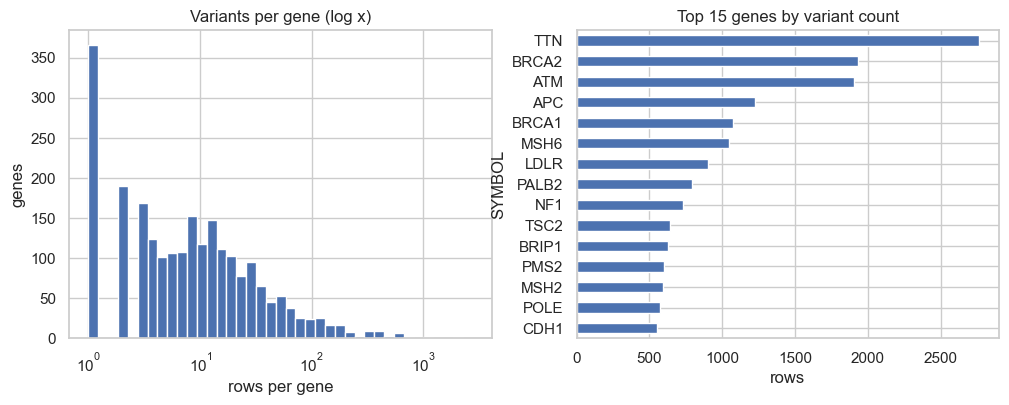

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(per_gene, bins=np.logspace(0, np.log10(per_gene.max()), 40))
ax[0].set(xscale="log", title="Variants per gene (log x)", xlabel="rows per gene", ylabel="genes")
per_gene.nlargest(15).sort_values().plot.barh(ax=ax[1])
ax[1].set(title="Top 15 genes by variant count", xlabel="rows")
save("01_rows_per_gene")

In [10]:
hc = col_table[col_table["type"].isin(["high_card_categorical", "free_text", "identifier"])]
hc[["type", "n_unique", "missing_%", "example"]]

,type,n_unique,missing_%,example
CLNDNINCL,free_text,101,99.7,Bull's_eye_maculopathy|Methylmalonic_aci
CLNDN,free_text,9260,0.0,not_specified
CLNDISDB,free_text,9234,0.0,MedGen:CN169374
CLNDISDBINCL,free_text,93,99.7,"MedGen:C1828210,OMIM:153870,Orphanet:ORP"
Amino_acids,high_card_categorical,1262,15.3,E/D
Codons,high_card_categorical,2220,15.3,gaG/gaC
SYMBOL,high_card_categorical,2328,0.0,B3GALT6
EXON,high_card_categorical,3264,13.6,1/1
Consequence,high_card_categorical,48,0.0,missense_variant
Allele,high_card_categorical,374,0.0,C


**Findings**

- 65,188 variants x 46 columns (~110 MB in memory); one file, no split. No rows with a missing target.
- The key `CHROM, POS, REF, ALT` is unique, and so is `CLNHGVS`, so one row = one variant.
- Three position columns were text (2,276 / 2,201 / 1,206 range values such as `943-944`, `?-117`) and were parsed to the first coordinate.
- **Repeated entity: gene.** 2,328 genes, median 7 variants per gene, p90 50, max 2,765 (TTN); the top 10 genes hold 20% of rows. Variants in the same gene are not independent, and p-values below are optimistic. This drives the split advice in Section 12.
- **Noted for manual treatment (not encoded here):** `SYMBOL` (2,328 levels), `Consequence` (48, multi-valued with `&`), `MC` (90), `EXON` / `INTRON` (`n/total` strings), `REF` / `ALT` / `Allele` (sequences), `Amino_acids`, `Codons`, and the ClinVar text fields `CLNDN`, `CLNDISDB`.
- Identifiers to exclude from modeling: `CLNHGVS`, `POS`, `Feature` (transcript ID), `CLNVI`.

## 2. Duplicates
Full-row duplicates, key duplicates, and variants that are identical on all annotation features but differ in the target.

In [11]:
ID_COLS = COL_TYPES["identifier"]
feat_cols = [c for c in df.columns if c not in ID_COLS + ["CLASS"]]

full_dup = df.duplicated().sum()
key_dup = df.duplicated(KEY).sum()
feat_dup = df.duplicated(feat_cols, keep=False)
conflicting = df[feat_dup].groupby(feat_cols, dropna=False)["CLASS"].nunique().gt(1).sum()

print(f"full-row duplicates: {full_dup}")
print(f"key duplicates: {key_dup}")
print(f"rows sharing all feature values with another row: {feat_dup.sum()} ({feat_dup.mean():.2%})")
print(f"  of which feature-groups with both CLASS values: {conflicting}")

full-row duplicates: 0
key duplicates: 0
rows sharing all feature values with another row: 0 (0.00%)
  of which feature-groups with both CLASS values: 0


**Findings**

- No full-row duplicates, no key duplicates, and no two variants share every feature value, so there are no conflicting duplicates.
- Nothing is dropped. The duplication risk is at gene level (many near-identical variants per gene), handled by grouping in Section 12.

## 3. Suspicious and invalid values
Range checks, spikes, near-constant columns, string artifacts and cross-field consistency.

In [12]:
issues = []


def add(col, issue, mask, action):
    mask = mask.fillna(False)
    ex = df.loc[mask, col].astype(str).head(1).tolist()
    issues.append({"column": col, "issue": issue, "count": int(mask.sum()),
                   "%": round(mask.mean() * 100, 2), "example": ex[0] if ex else "", "action": action})


for c in ["AF_ESP", "AF_EXAC", "AF_TGP"]:
    add(c, "outside [0, 1]", ~df[c].between(0, 1), "none found")
    add(c, "spike at 0 (not observed in cohort vs. true 0 is ambiguous)", df[c].eq(0), "keep, flag for modeling")
add("LoFtool", "outside [0, 1]", ~df["LoFtool"].between(0, 1) & df["LoFtool"].notna(), "none found")
add("CADD_PHRED", "spike at cap 99", df["CADD_PHRED"].eq(99), "keep, genuine cap")
add("CDS_position", "CDS > cDNA position (CDS should sit inside cDNA)", df["CDS_position"] > df["cDNA_position"], "check")
prot_gap = (np.ceil(df["CDS_position"] / 3) - df["Protein_position"]).abs()
add("Protein_position", "!= ceil(CDS/3) by more than 1", prot_gap > 1, "check")
add("Allele", "'-' (VEP notation for deleted allele, not a null)", df["Allele"].eq("-"), "keep")

for c in df.columns:
    s = df[c].dropna()
    if len(s) and s.value_counts(normalize=True).iloc[0] >= 0.99:
        add(c, f"near-constant (top level {s.value_counts(normalize=True).iloc[0]:.1%} of non-null)",
            df[c].notna(), "drop candidate")
    if s.dtype == object and (s != s.str.strip()).any():
        add(c, "leading/trailing whitespace", df[c].astype(str) != df[c].astype(str).str.strip(), "strip")

issues_df = pd.DataFrame(issues)
issues_df[issues_df["count"] > 0]

,column,issue,count,%,example,action
1,AF_ESP,spike at 0 (not observed in cohort vs. true 0 ...,35781,54.89,0.0,"keep, flag for modeling"
3,AF_EXAC,spike at 0 (not observed in cohort vs. true 0 ...,24047,36.89,0.0,"keep, flag for modeling"
5,AF_TGP,spike at 0 (not observed in cohort vs. true 0 ...,37972,58.25,0.0,"keep, flag for modeling"
7,CADD_PHRED,spike at cap 99,1,0.00,99.0,"keep, genuine cap"
8,CDS_position,CDS > cDNA position (CDS should sit inside cDNA),2,0.00,422.0,check
10,Allele,"'-' (VEP notation for deleted allele, not a null)",2510,3.85,-,keep
11,Feature_type,near-constant (top level 100.0% of non-null),65174,99.98,Transcript,drop candidate
12,BIOTYPE,near-constant (top level 100.0% of non-null),65172,99.98,protein_coding,drop candidate
13,BAM_EDIT,near-constant (top level 99.2% of non-null),31969,49.04,OK,drop candidate
14,MOTIF_POS,near-constant (top level 100.0% of non-null),2,0.00,1.0,drop candidate


**Findings**

- No out-of-range values: allele frequencies are within [0, 0.5] (they are minor-allele frequencies), `LoFtool` within [0, 1], `CADD_PHRED` max 99 (one variant at the cap).
- **Zero spike in allele frequencies:** 55% (ESP), 37% (ExAC), 58% (1000 Genomes) of rows are exactly 0. In these sources a 0 most likely means "not observed in the cohort", not a measured frequency of 0. Kept as-is; a model should see zero as its own state (tree models handle this naturally).
- `Allele = '-'` in 2,510 rows is VEP notation for a deleted allele, not a null, and is kept.
- Cross-field checks: only 2 rows have CDS position > cDNA position, negligible.
- **Near-constant columns (drop):** `Feature_type`, `BIOTYPE` (100% one level), `BAM_EDIT` (99.2% `OK` when present), `MOTIF_POS`, `HIGH_INF_POS`, plus the 99.7-100% empty `MOTIF_*`, `DISTANCE`, `SSR`, `CLN*INCL` (Section 5).
- No whitespace or casing artifacts.

## 4. Target
Class balance of `CLASS`. There is no time column, so drift over time cannot be checked.

       count  share
CLASS              
0      48754  0.748
1      16434  0.252
imbalance ratio 0:1 = 2.97


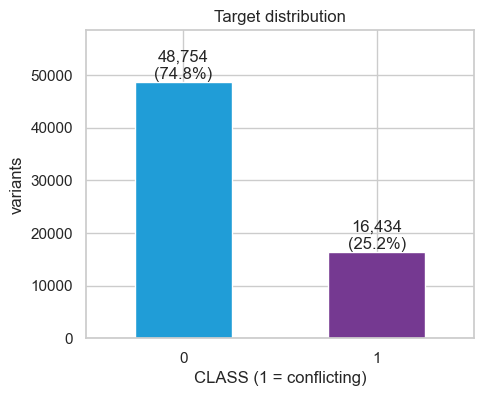

In [13]:
counts = df["CLASS"].value_counts().sort_index()
share = counts / counts.sum()
print(pd.DataFrame({"count": counts, "share": share.round(3)}))
print(f"imbalance ratio 0:1 = {counts[0] / counts[1]:.2f}")

ax = counts.plot.bar(color=["#209dd7", "#753991"], figsize=(5, 4), rot=0)
for i, (n, p) in enumerate(zip(counts, share)):
    ax.text(i, n, f"{n:,}\n({p:.1%})", ha="center", va="bottom")
ax.set(title="Target distribution", xlabel="CLASS (1 = conflicting)", ylabel="variants", ylim=(0, counts.max() * 1.2))
save("04_target")

**Findings**

- 48,754 consistent (74.8%) vs. 16,434 conflicting (25.2%); imbalance ratio 2.97:1.
- Moderate imbalance: use stratified folds, and report PR-AUC (baseline 0.25) alongside ROC-AUC. Accuracy is misleading (75% for the trivial model). Class weights are optional; calibrate probabilities if the score will be used as a review-priority threshold.

## 5. Missing values
Disguised nulls first, then missing share, co-occurrence, mechanism (MCAR / MAR / MNAR) and relation to the target.

In [14]:
NULL_TOKENS = {"NA", "N/A", "null", "None", "", "?", "-"}
disguised = {c: int(df[c].astype(str).str.strip().isin(NULL_TOKENS).sum())
             for c in df.select_dtypes("object") if c != "Allele"}
print("disguised null tokens per column (Allele '-' excluded, it means deletion):",
      {k: v for k, v in disguised.items() if v} or "none")

disguised null tokens per column (Allele '-' excluded, it means deletion): none


MOTIF_SCORE_CHANGE    100.00
HIGH_INF_POS          100.00
MOTIF_POS             100.00
MOTIF_NAME            100.00
DISTANCE               99.83
SSR                    99.80
CLNSIGINCL             99.74
CLNDISDBINCL           99.74
CLNDNINCL              99.74
INTRON                 86.50
PolyPhen               61.96
SIFT                   61.90
BLOSUM62               60.74
CLNVI                  57.57
BAM_EDIT               50.96
Codons                 15.35
Amino_acids            15.35
Protein_position       15.27
CDS_position           15.27
EXON                   13.64
cDNA_position          13.63
LoFtool                 6.46
CADD_PHRED              1.68
CADD_RAW                1.68
MC                      1.30
STRAND                  0.02
Feature_type            0.02
BIOTYPE                 0.02
SYMBOL                  0.02
Feature                 0.02


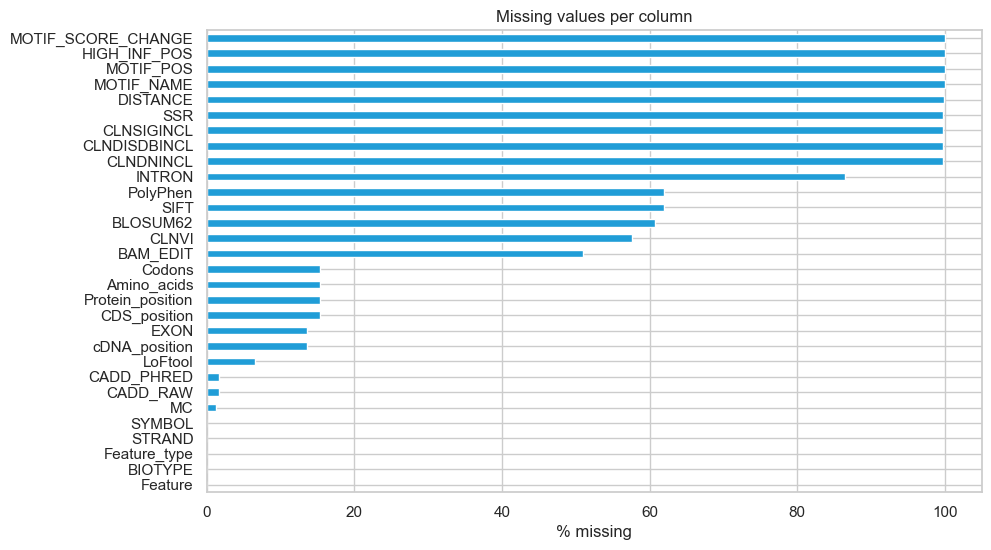

In [15]:
miss = df.isna().mean().mul(100).round(2).sort_values(ascending=False)
miss = miss[miss > 0]
print(miss.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
miss.sort_values().plot.barh(ax=ax, color="#209dd7")
ax.set(title="Missing values per column", xlabel="% missing")
save("05_missing_bar")

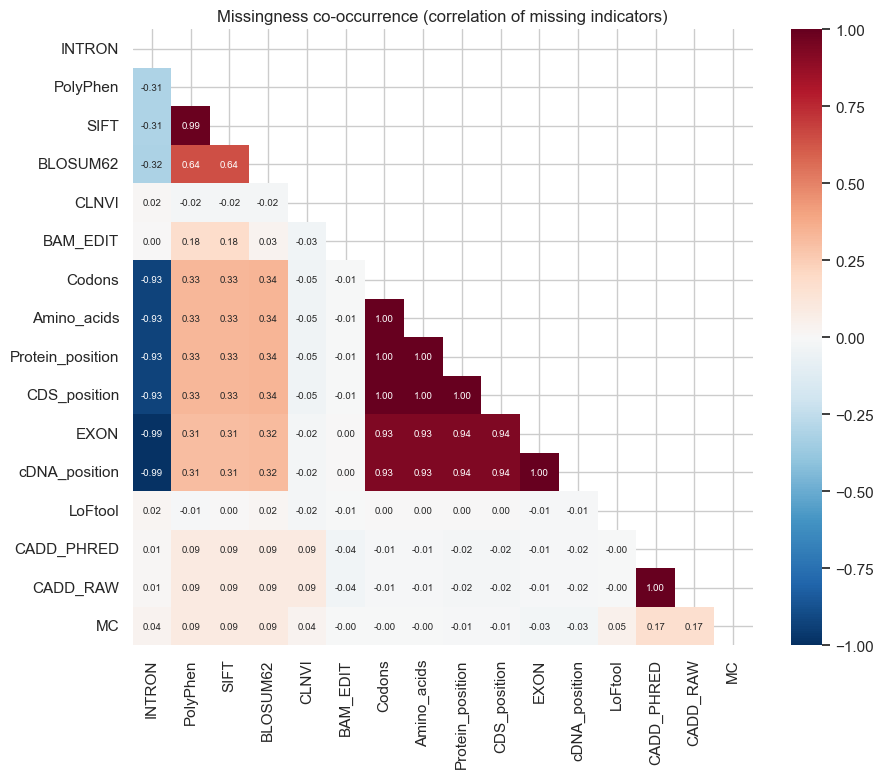

In [16]:
partial = miss[(miss > 0.5) & (miss < 99.5)].index
co = df[partial].isna().astype(int).corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(co, dtype=bool))
sns.heatmap(co, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("Missingness co-occurrence (correlation of missing indicators)")
save("05_missing_cooccurrence")

**MCAR - Little's test** on the numeric columns (standardized). With 65k rows the test rejects for tiny departures, so its role is only to confirm that MCAR is not a safe assumption.

In [17]:
def little_mcar(X):
    X = (X - X.mean()) / X.std()
    mu, S, p = X.mean(), X.cov(), X.shape[1]
    patterns = X.isna().to_numpy() @ (1 << np.arange(p))
    d2, dof = 0.0, 0
    for _, g in X.groupby(patterns):
        obs = g.columns[g.iloc[0].notna()]
        diff = (g[obs].mean() - mu[obs]).to_numpy()
        d2 += len(g) * diff @ np.linalg.pinv(S.loc[obs, obs].to_numpy()) @ diff
        dof += len(obs)
    dof -= p
    return d2, dof, stats.chi2.sf(d2, dof)


mcar_cols = ["AF_ESP", "AF_EXAC", "AF_TGP", "LoFtool", "CADD_PHRED", "BLOSUM62", "CDS_position"]
d2, dof, p = little_mcar(df[mcar_cols])
print(f"Little's MCAR: chi2 = {d2:,.0f}, df = {dof}, p = {p:.2g}")

Little's MCAR: chi2 = 9,034, df = 53, p = 0


**MAR** - predict each column's missing indicator from fully observed columns with a depth-4 tree (3-fold CV AUC). AUC near 1 means missingness is almost fully explained by observed data.

In [18]:
obs_X = pd.get_dummies(df[["AF_ESP", "AF_EXAC", "AF_TGP", "STRAND", "IMPACT", "CLNVC", "Feature_type"]], dtype=float)
tree = DecisionTreeClassifier(max_depth=4, random_state=SEED)
mar = pd.Series({c: cross_val_score(tree, obs_X, df[c].isna(), cv=3, scoring="roc_auc").mean()
                 for c in partial}).round(3).sort_values(ascending=False)
mar.to_frame("missing-indicator AUC")

,missing-indicator AUC
CADD_PHRED,0.989
CADD_RAW,0.989
MC,0.958
Codons,0.918
Amino_acids,0.918
Protein_position,0.918
CDS_position,0.918
SIFT,0.916
PolyPhen,0.913
BLOSUM62,0.913


In [19]:
rows = []
for c in miss.index[miss < 99.5]:
    m = df[c].isna()
    t = pd.crosstab(m, df["CLASS"])
    chi2, pv, _, _ = stats.chi2_contingency(t)
    v = np.sqrt(chi2 / len(df))
    rows.append({"column": c, "rate_missing": df.loc[m, "CLASS"].mean(), "rate_present": df.loc[~m, "CLASS"].mean(),
                 "cramers_v": v, "p": pv})
mt = pd.DataFrame(rows)
mt["p_bh"] = multipletests(mt["p"], method="fdr_bh")[1]
mt.round(4).sort_values("cramers_v", ascending=False)

,column,rate_missing,rate_present,cramers_v,p,p_bh
4,CLNVI,0.2003,0.3224,0.1389,0.0000,0.0000
13,CADD_PHRED,0.1190,0.2544,0.0399,0.0000,0.0000
14,CADD_RAW,0.1190,0.2544,0.0399,0.0000,0.0000
8,Protein_position,0.2759,0.2478,0.0233,0.0000,0.0000
9,CDS_position,0.2759,0.2478,0.0233,0.0000,0.0000
6,Codons,0.2756,0.2478,0.0230,0.0000,0.0000
7,Amino_acids,0.2756,0.2478,0.0230,0.0000,0.0000
3,BLOSUM62,0.2448,0.2634,0.0209,0.0000,0.0000
2,SIFT,0.2453,0.2632,0.0200,0.0000,0.0000
1,PolyPhen,0.2456,0.2626,0.0189,0.0000,0.0000


**Findings**

- No disguised null tokens.
- **Nine columns are 99.7-100% empty** (`MOTIF_*`, `HIGH_INF_POS`, `DISTANCE`, `SSR`, `CLNSIGINCL`, `CLNDISDBINCL`, `CLNDNINCL`): drop.
- **Missingness is structural (MAR, explained by variant type):** protein-level fields (`SIFT`, `PolyPhen`, `BLOSUM62`, ~61% missing) exist only for missense variants; `Codons` / `Amino_acids` / `CDS_position` / `Protein_position` (15%) only for coding variants; `EXON` and `INTRON` are complementary. The co-occurrence heatmap shows these blocks, and a depth-4 tree predicts the indicators from `IMPACT` / `CLNVC` / allele frequencies with AUC 0.90-0.99.
- Little's MCAR test rejects MCAR (chi2 = 9,034, df = 53, p ~ 0). With 65k rows this is expected, but it is consistent with the structural mechanism above.
- MNAR: `CLNVI` (57.6% missing) is plausibly MNAR. A variant gets an external ID (OMIM, UniProt) when it has been studied, which also makes more submissions, and therefore conflicts, more likely. `LoFtool` (6.5%) is missing for genes without a score, and its indicator is not predictable from the observed data (AUC 0.53).
- **Missingness vs. target:** the only notable effect is `CLNVI` (rate 20.0% when missing vs. 32.2% when present, Cramer's V 0.14); see leakage in Section 11. `CADD` missing (1.7%, indels) has an 11.9% vs. 25.4% conflict rate. All other effects are V < 0.03. For protein-level scores, "missing" = "not missense", so a tree model needs no extra indicator; for a linear model add indicators.

## 6. Numeric distributions
Summary statistics, shape (histogram, QQ, log view) and outliers for the continuous columns. `DISTANCE` is 99.8% missing and skipped. Plots use a 20k-row sample (seed 42); statistics use all rows.

In [20]:
NUM = ["AF_ESP", "AF_EXAC", "AF_TGP", "LoFtool", "CADD_PHRED", "CADD_RAW",
       "cDNA_position", "CDS_position", "Protein_position"]
desc = df[NUM].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc["skew"] = df[NUM].skew()
desc["zero_%"] = (df[NUM] == 0).mean() * 100
desc.round(3)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,zero_%
AF_ESP,65188.0,0.015,0.058,0.000,0.000,0.000,0.000,0.000,0.001,0.076,0.356,0.499,5.466,54.889
AF_EXAC,65188.0,0.014,0.060,0.000,0.000,0.000,0.000,0.000,0.001,0.077,0.370,0.500,5.434,36.889
AF_TGP,65188.0,0.015,0.060,0.000,0.000,0.000,0.000,0.000,0.002,0.084,0.366,0.500,5.329,58.250
LoFtool,60975.0,0.345,0.361,0.000,0.000,0.001,0.024,0.157,0.710,0.971,0.995,1.000,0.652,0.000
CADD_PHRED,64096.0,15.686,10.836,0.001,0.002,0.070,7.141,14.090,24.100,34.000,40.000,99.000,0.379,0.000
CADD_RAW,64096.0,2.554,2.962,-5.477,-1.769,-0.706,0.463,1.643,4.381,7.455,12.711,46.556,1.609,0.000
cDNA_position,56304.0,5058.885,13100.782,1.000,104.000,284.000,911.000,1844.000,3900.000,13114.700,87173.580,108207.000,5.585,0.000
CDS_position,55233.0,4897.622,13204.047,1.000,25.000,131.000,709.000,1626.000,3692.000,13213.200,87468.440,107961.000,5.538,0.000
Protein_position,55233.0,1632.858,4401.355,1.000,9.000,44.000,237.000,542.000,1231.000,4404.800,29156.360,35987.000,5.538,0.000


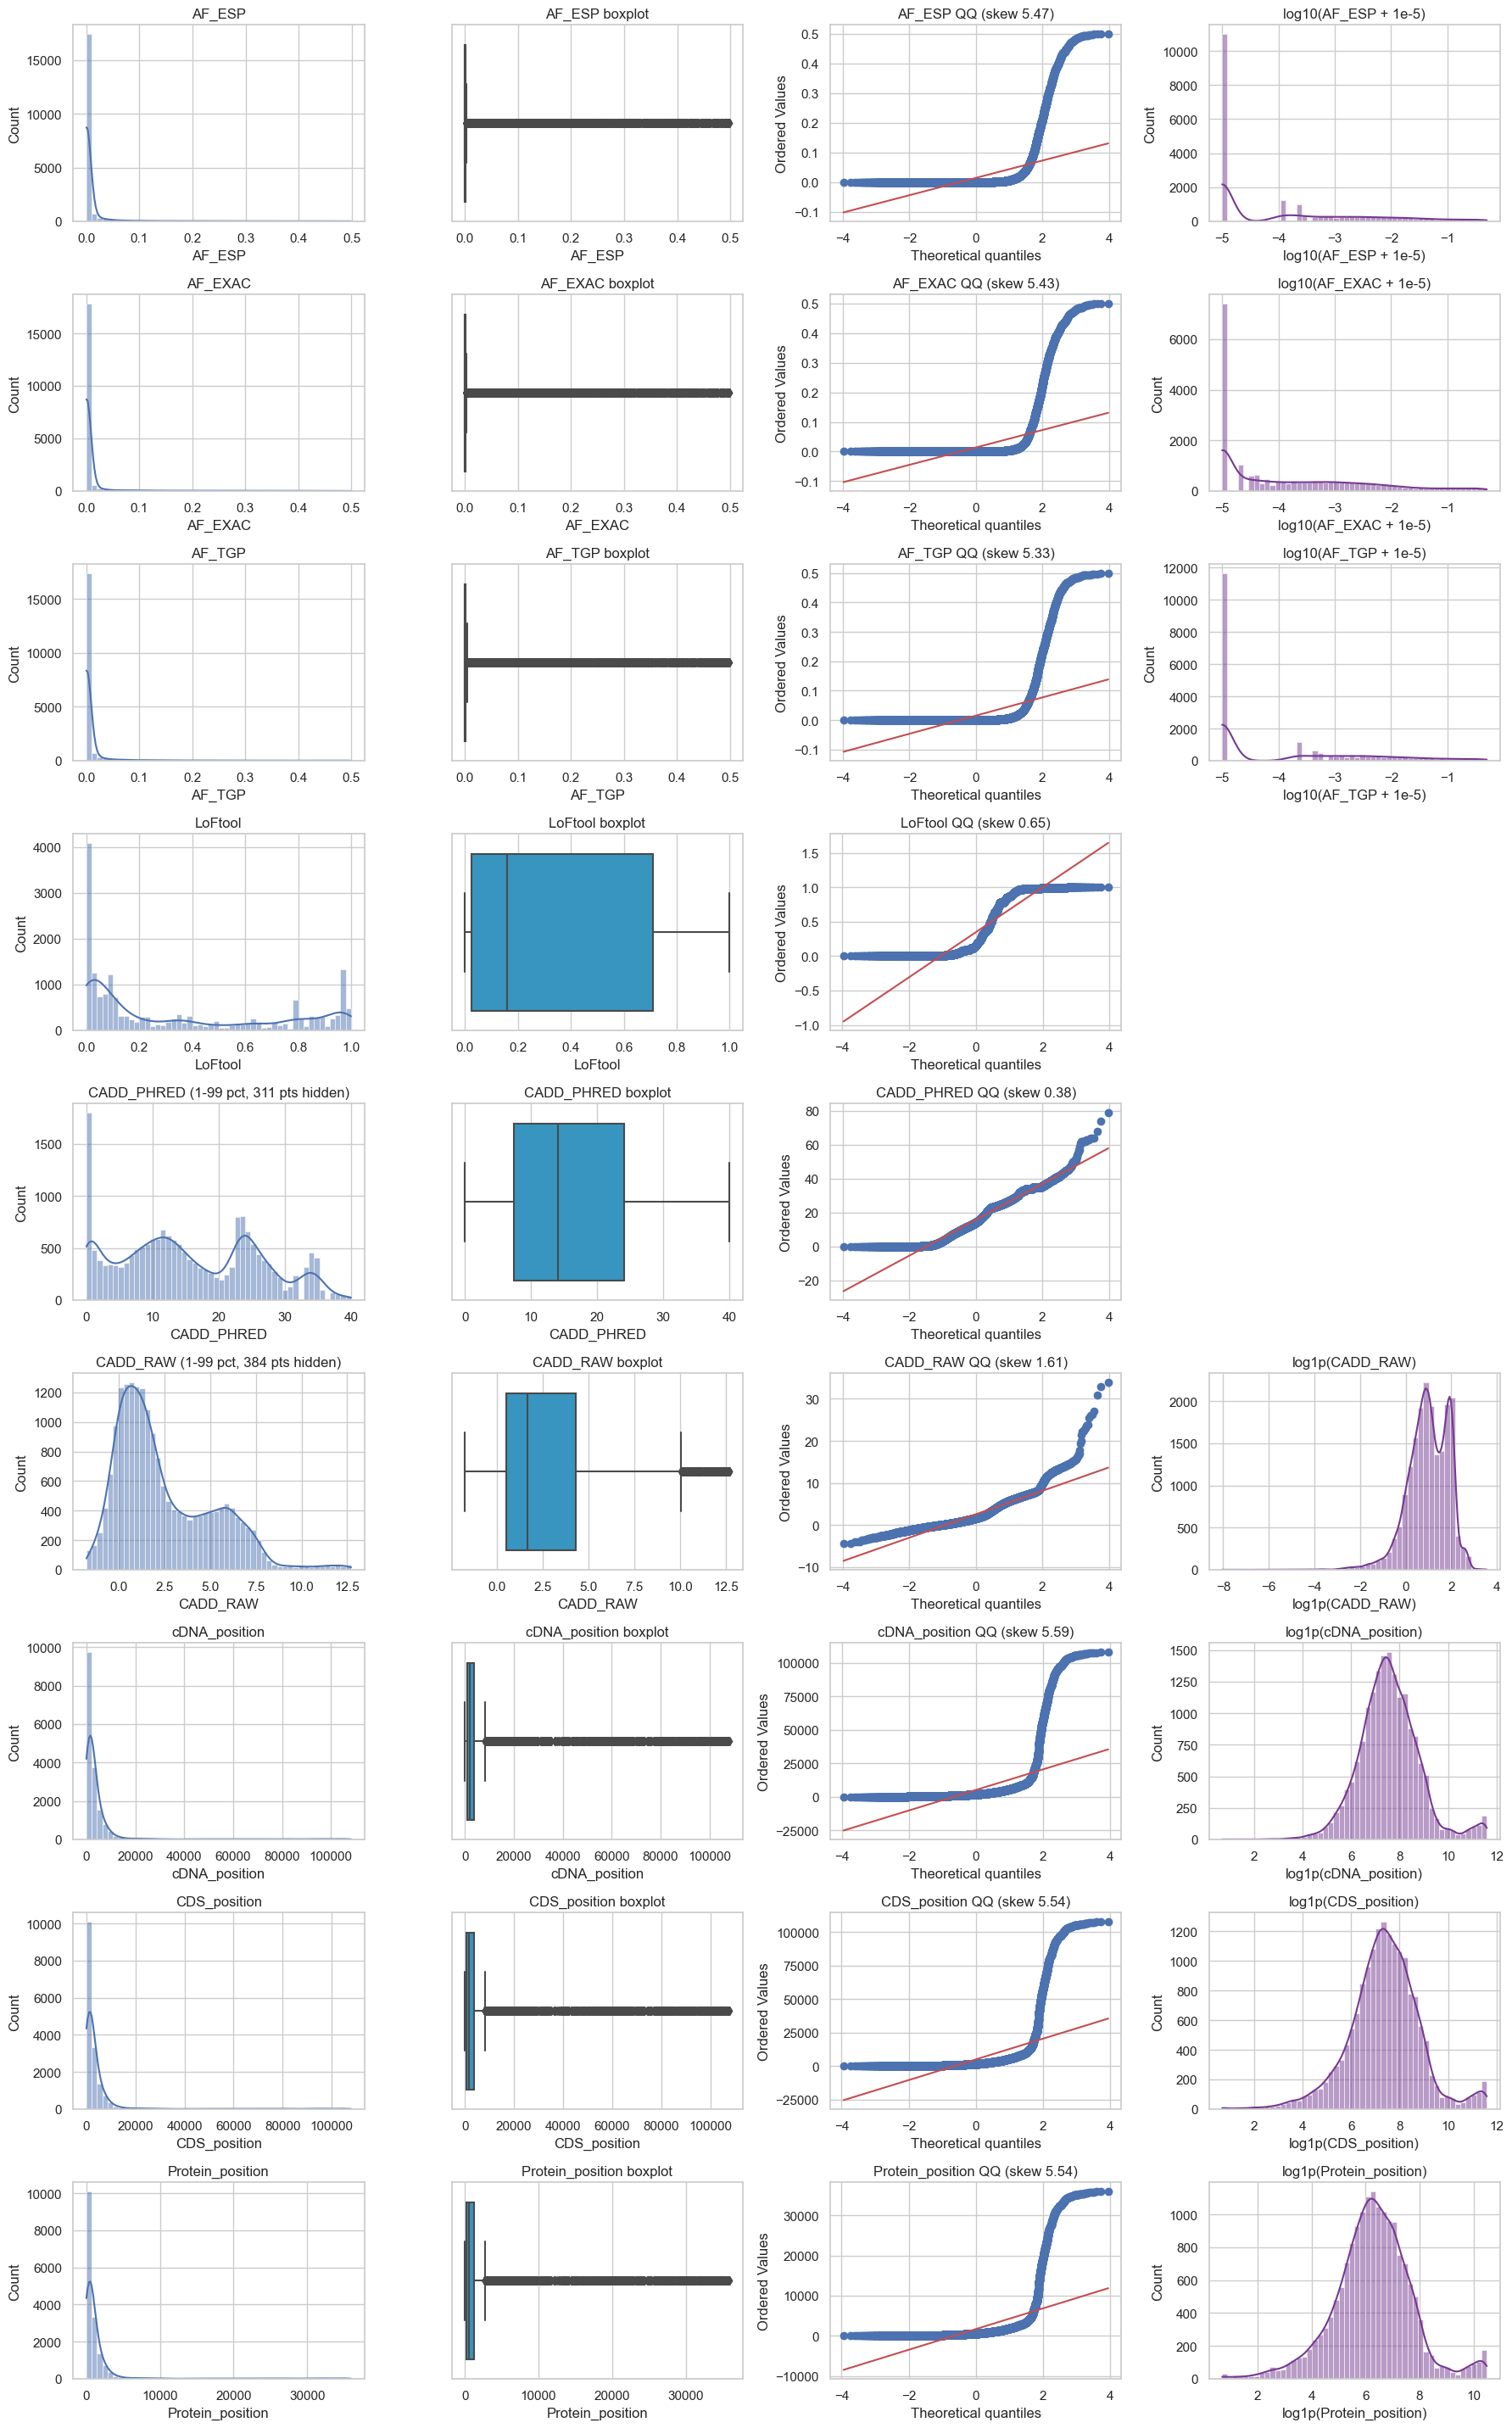

In [21]:
sample = df.sample(20_000, random_state=SEED)
fig, axes = plt.subplots(len(NUM), 4, figsize=(18, 3.2 * len(NUM)))
for ax, c in zip(axes, NUM):
    s_full, s = df[c].dropna(), sample[c].dropna()
    lo, hi = s_full.quantile([.01, .99])
    clip = s_full.max() > hi * 1.5 and hi > 0
    view = s[s.between(lo, hi)] if clip else s
    sns.histplot(view, kde=True, ax=ax[0], bins=50)
    ax[0].set(title=f"{c}" + (f" (1-99 pct, {len(s) - len(view)} pts hidden)" if clip else ""), xlabel=c)
    sns.boxplot(x=view, ax=ax[1], color="#209dd7")
    ax[1].set(title=f"{c} boxplot", xlabel=c)
    stats.probplot(s, plot=ax[2])
    ax[2].set_title(f"{c} QQ (skew {s_full.skew():.2f})")
    if abs(s_full.skew()) > 1:
        # frequencies live in [0, 0.5], where log1p is ~identity -> use log10 with a small offset
        lg, name = (np.log10(s + 1e-5), f"log10({c} + 1e-5)") if s_full.max() <= 1 else (np.log1p(s), f"log1p({c})")
        sns.histplot(lg, kde=True, ax=ax[3], bins=50, color="#753991")
        ax[3].set(title=name, xlabel=name)
    else:
        ax[3].axis("off")
plt.tight_layout()
save("06_numeric_distributions")

In [22]:
def outlier_counts(s):
    s = s.dropna()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    mad = stats.median_abs_deviation(s)
    rz = 0.6745 * (s - s.median()) / mad if mad > 0 else pd.Series(np.nan, index=s.index)
    return pd.Series({"iqr_flagged": int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()),
                      "iqr_upper_fence": q3 + 1.5 * iqr,
                      "mad_flagged": int((rz.abs() > 3.5).sum()) if mad > 0 else None,
                      "max": s.max(), "n_removed": 0,
                      "reason": "genuine extreme, no removal"})


outliers = df[NUM].apply(outlier_counts).T
outliers

,iqr_flagged,iqr_upper_fence,mad_flagged,max,n_removed,reason
AF_ESP,12721,0.003,None,0.499,0,"genuine extreme, no removal"
AF_EXAC,11866,0.003075,24567,0.49989,0,"genuine extreme, no removal"
AF_TGP,12037,0.004,None,0.4998,0,"genuine extreme, no removal"
LoFtool,0,1.73855,5685,1.0,0,"genuine extreme, no removal"
CADD_PHRED,131,49.5385,48,99.0,0,"genuine extreme, no removal"
CADD_RAW,1367,10.259053,1531,46.556261,0,"genuine extreme, no removal"
cDNA_position,5162,8383.5,5691,108207.0,0,"genuine extreme, no removal"
CDS_position,5060,8166.5,5656,107961.0,0,"genuine extreme, no removal"
Protein_position,5060,2722.0,5660,35987.0,0,"genuine extreme, no removal"


**Findings**

- **Allele frequencies** are extremely right-skewed (skew ~5.4), median 0, p99 ~0.36. The `log10(AF + 1e-5)` view shows a spike of zeros and a broad mode around 1e-4 to 1e-2. Use this log transform (or trees) rather than raw values.
- `CADD_PHRED` is multi-modal (peaks near 0, 12, 24, 34, from the variant-class mix) and near-symmetric (skew 0.38). `CADD_RAW` has the same ranking (Spearman 1.0); keep one.
- `LoFtool` is bimodal (peaks at 0 and 1), bounded, skew 0.65, no transform needed.
- Positions (`cDNA` / `CDS` / `Protein`) are right-skewed (skew 5.5) with a secondary cluster above 80k, the giant TTN gene. They are log-normal after `log1p`.
- IQR / MAD flag thousands of points for AF and positions, but these are real (common variants, long genes). **No values removed.**

## 7. Categorical and low-cardinality columns
Spelling consistency, level counts, rare levels and dominant levels, each column on its own.

In [23]:
CAT = ["CHROM", "CLNVC", "ORIGIN", "IMPACT", "Feature_type", "BIOTYPE", "BAM_EDIT",
       "SIFT", "PolyPhen", "BLOSUM62", "STRAND"]

spelling = []
for c in CAT:
    levels = df[c].dropna().astype(str).unique()
    norm = {l: l.strip().lower().replace("-", "_").replace(" ", "_") for l in levels}
    for i, a in enumerate(levels):
        for b in levels[i + 1:]:
            r = difflib.SequenceMatcher(None, norm[a], norm[b]).ratio()
            if r >= 0.9:
                spelling.append({"column": c, "level_a": a, "level_b": b, "ratio": round(r, 2)})
print("fuzzy matches (ratio >= 0.9):", pd.DataFrame(spelling) if spelling else "none")

fuzzy matches (ratio >= 0.9): none


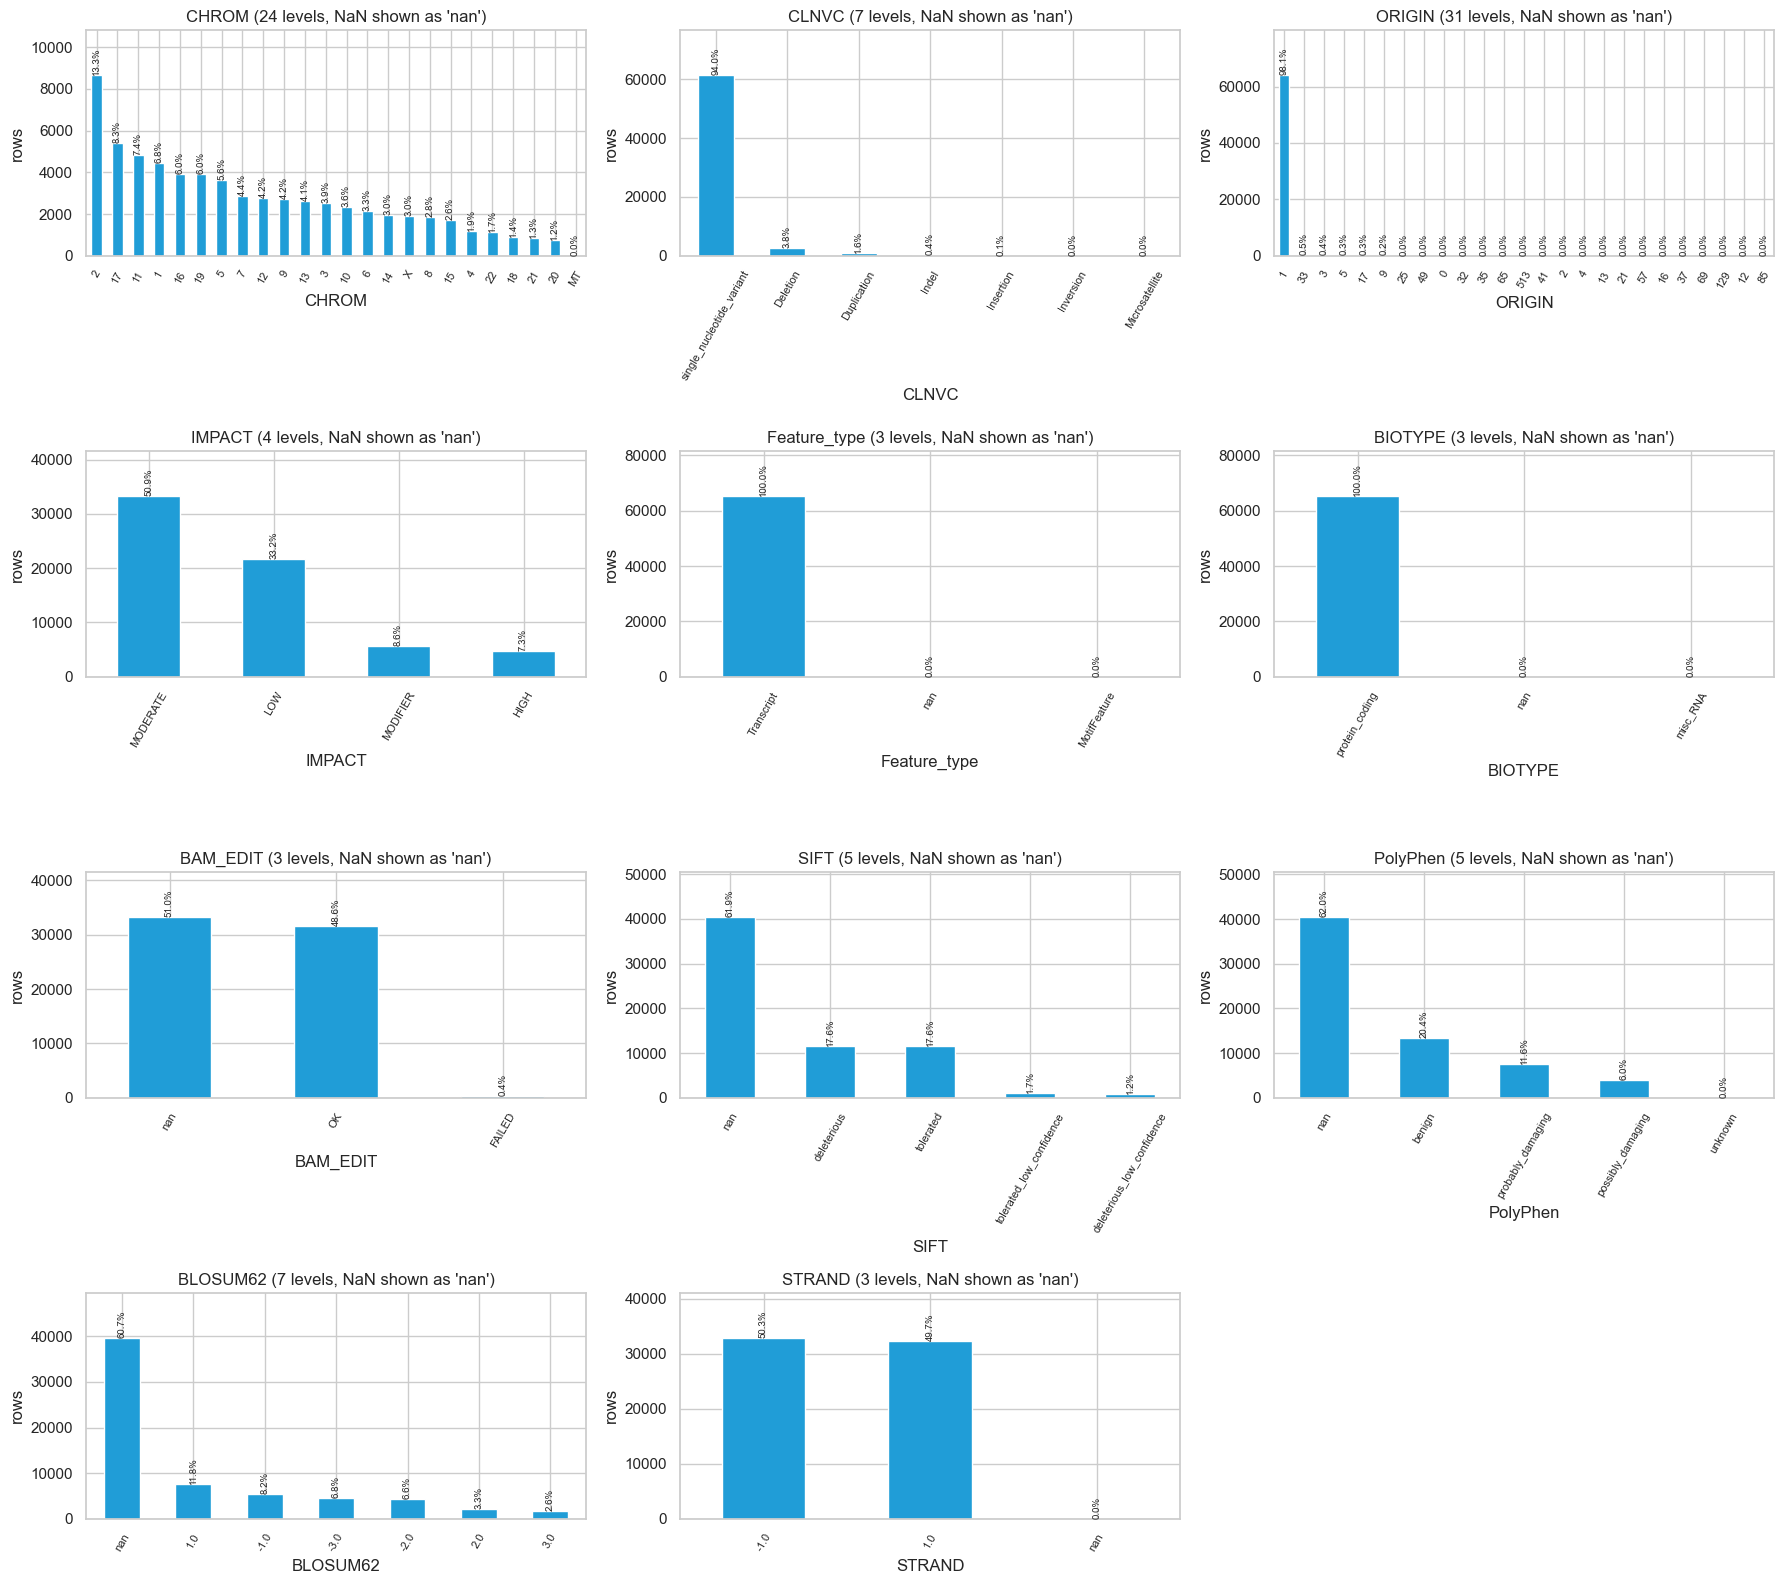

In [24]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for ax, c in zip(axes.flat, CAT):
    vc = df[c].astype(str).value_counts()
    top = vc.head(25)
    top.plot.bar(ax=ax, color="#209dd7")
    for i, n in enumerate(top):
        ax.text(i, n, f"{n / len(df):.1%}", ha="center", va="bottom", fontsize=7, rotation=90)
    ax.set(title=f"{c} ({len(vc)} levels, NaN shown as 'nan')", ylabel="rows", ylim=(0, top.max() * 1.25))
    ax.tick_params(axis="x", labelrotation=60, labelsize=8)
axes.flat[-1].axis("off")
plt.tight_layout()
save("07_categorical_counts")

In [25]:
rows = []
for c in CAT:
    vc = df[c].astype(str).value_counts()
    rare = vc[(vc / len(df) < 0.01) | (vc < 30)]
    rows.append({"column": c, "levels": len(vc), "top_level": vc.index[0], "top_share": round(vc.iloc[0] / len(df), 3),
                 "dominant(>=90%)": vc.iloc[0] / len(df) >= 0.9, "n_rare_levels": len(rare),
                 "rare_levels": ", ".join(rare.index[:8])})
pd.DataFrame(rows)

,column,levels,top_level,top_share,dominant(>=90%),n_rare_levels,rare_levels
0,CHROM,24,2,0.133,False,1,MT
1,CLNVC,7,single_nucleotide_variant,0.940,True,4,"Indel, Insertion, Inversion, Microsatellite"
2,ORIGIN,31,1,0.981,True,30,"33, 3, 5, 17, 9, 25, 49, 0"
3,IMPACT,4,MODERATE,0.509,False,0,
4,Feature_type,3,Transcript,1.000,True,2,"nan, MotifFeature"
5,BIOTYPE,3,protein_coding,1.000,True,2,"nan, misc_RNA"
6,BAM_EDIT,3,nan,0.510,False,1,FAILED
7,SIFT,5,nan,0.619,False,0,
8,PolyPhen,5,nan,0.620,False,1,unknown
9,BLOSUM62,7,nan,0.607,False,0,


**Findings**

- No spelling variants (all fuzzy ratios < 0.9); the vocabularies are controlled.
- **Dominant levels:** `CLNVC` is 94% single nucleotide variants, so the model will learn little about indels, duplications and inversions. `ORIGIN` is 98.1% germline (`1`), with 30 rare bit-code combinations; group them as "germline" vs. "other". `Feature_type` / `BIOTYPE` are constant.
- `IMPACT` is well spread (MODERATE 51%, LOW 33%, MODIFIER 9%, HIGH 7%).
- Rare levels: `CHROM=MT` (16 rows), four rare `CLNVC` types, 30 rare `ORIGIN` codes. Group them into "Other".
- `SIFT` / `PolyPhen` / `BLOSUM62` are mostly `NaN` (not missense); the missing level itself is informative about variant type.

## 8. Date and time columns
There are no date or time columns (ClinVar submission dates are not included in this extract), so time trends, gaps and drift cannot be assessed. This matters for Section 12: an out-of-time holdout is not possible.

## 9. Feature-feature relationships (target excluded)

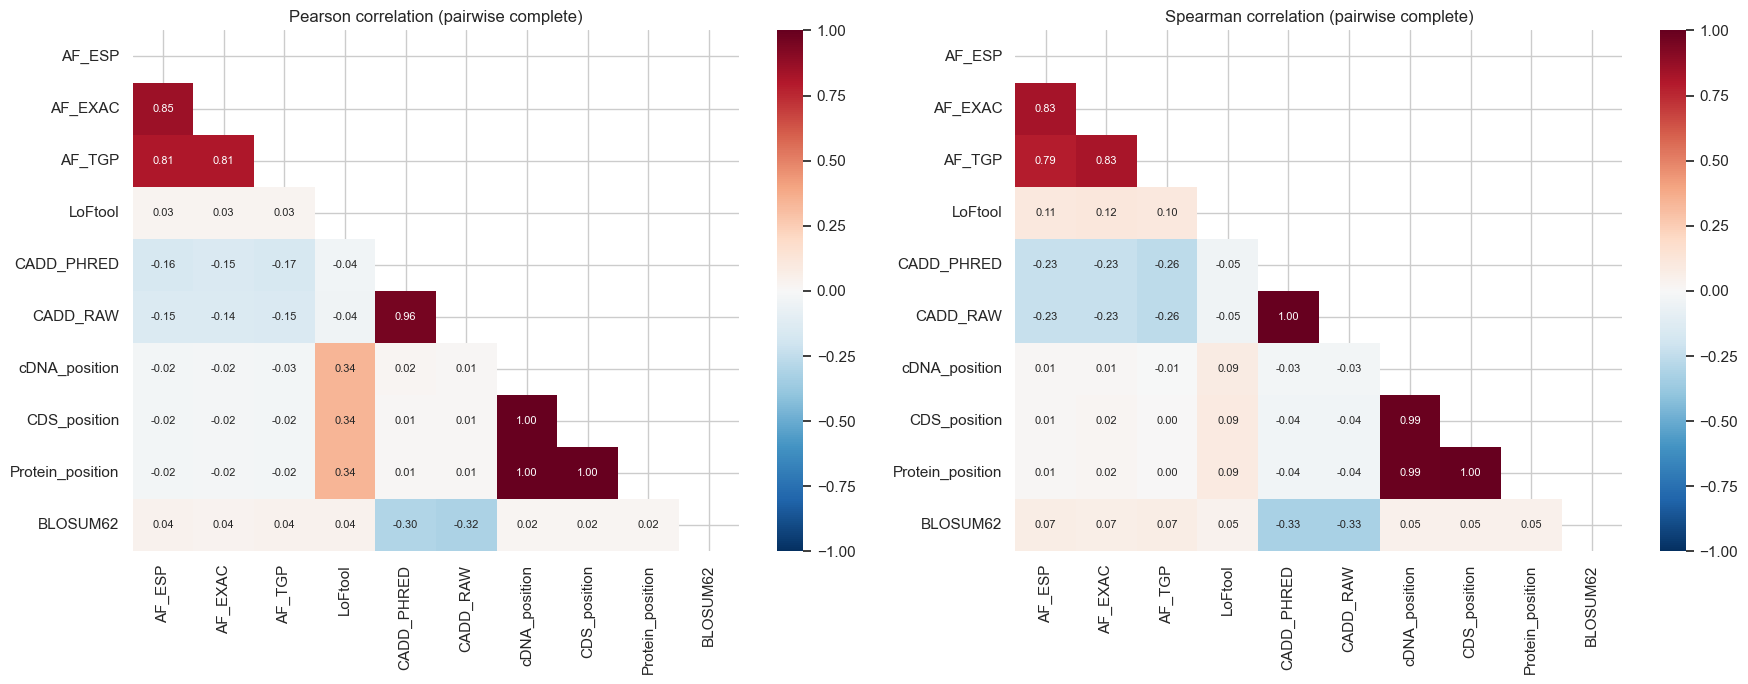

pearson  spearman   diff
AF_EXAC          AF_ESP           0.852     0.834  0.018
AF_TGP           AF_ESP           0.808     0.786  0.022
                 AF_EXAC          0.806     0.826  0.020
CADD_RAW         CADD_PHRED       0.955     1.000  0.045
cDNA_position    LoFtool          0.338     0.085  0.253
CDS_position     LoFtool          0.341     0.094  0.247
                 cDNA_position    1.000     0.989  0.011
Protein_position LoFtool          0.341     0.094  0.247
                 cDNA_position    1.000     0.989  0.011
                 CDS_position     1.000     1.000  0.000

In [26]:
NUM9 = NUM + ["BLOSUM62"]
pear, spear = df[NUM9].corr("pearson"), df[NUM9].corr("spearman")
mask = np.triu(np.ones_like(pear, dtype=bool))
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
for a, m, name in [(ax[0], pear, "Pearson"), (ax[1], spear, "Spearman")]:
    sns.heatmap(m, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=a, annot_kws={"size": 8})
    a.set_title(f"{name} correlation (pairwise complete)")
plt.tight_layout()
save("09_numeric_correlation")

pairs = pd.DataFrame({"pearson": pear.where(~mask).stack(), "spearman": spear.where(~mask).stack()})
pairs["diff"] = (pairs["pearson"] - pairs["spearman"]).abs()
pairs[(pairs[["pearson", "spearman"]].abs().max(axis=1) > 0.8) | (pairs["diff"] > 0.2)].round(3)

Categorical vs. numeric: Mann-Whitney U with rank-biserial effect for two-level columns, Kruskal-Wallis with epsilon-squared for more levels. BH-corrected across all pairs.

In [27]:
CAT9 = ["CLNVC", "IMPACT", "BAM_EDIT", "SIFT", "PolyPhen", "STRAND", "Feature_type"]
NUM9B = ["AF_EXAC", "LoFtool", "CADD_PHRED", "CDS_position"]
rows = []
for c in CAT9:
    for n in NUM9B:
        d = df[[c, n]].dropna()
        groups = [g[n].to_numpy() for _, g in d.groupby(c) if len(g) >= 30]
        if len(groups) < 2:
            continue
        if len(groups) == 2:
            u, p = stats.mannwhitneyu(*groups)
            eff, test = 1 - 2 * u / (len(groups[0]) * len(groups[1])), "MWU r_rb"
        else:
            h, p = stats.kruskal(*groups)
            eff, test = (h - len(groups) + 1) / (len(d) - len(groups)), "KW eps2"
        rows.append({"categorical": c, "numeric": n, "test": test, "effect": eff, "p": p, "n": len(d)})
cn = pd.DataFrame(rows)
cn["p_bh"] = multipletests(cn["p"], method="fdr_bh")[1]
cn.assign(abs_effect=cn["effect"].abs()).sort_values("abs_effect", ascending=False).head(12).round(4)

,categorical,numeric,test,effect,p,n,p_bh,abs_effect
18,PolyPhen,CADD_PHRED,KW eps2,0.5124,0.0000,24753,0.0000,0.5124
14,SIFT,CADD_PHRED,KW eps2,0.4978,0.0000,24792,0.0000,0.4978
8,BAM_EDIT,AF_EXAC,MWU r_rb,0.4255,0.0000,31969,0.0000,0.4255
6,IMPACT,CADD_PHRED,KW eps2,0.3808,0.0000,64096,0.0000,0.3808
11,BAM_EDIT,CDS_position,MWU r_rb,0.1812,0.0000,27022,0.0000,0.1812
21,STRAND,LoFtool,MWU r_rb,-0.1549,0.0000,60975,0.0000,0.1549
9,BAM_EDIT,LoFtool,MWU r_rb,0.0925,0.0098,29858,0.0112,0.0925
10,BAM_EDIT,CADD_PHRED,MWU r_rb,-0.0910,0.0126,31272,0.0137,0.0910
20,STRAND,AF_EXAC,MWU r_rb,-0.0893,0.0000,65174,0.0000,0.0893
4,IMPACT,AF_EXAC,KW eps2,0.0868,0.0000,65188,0.0000,0.0868


In [28]:
# Pairwise follow-up for the strongest multi-level pair: CADD_PHRED across IMPACT levels
d = df[["IMPACT", "CADD_PHRED"]].dropna()
lv = ["HIGH", "MODERATE", "LOW", "MODIFIER"]
pw = []
for i, a in enumerate(lv):
    for b in lv[i + 1:]:
        x, y = d.loc[d.IMPACT == a, "CADD_PHRED"], d.loc[d.IMPACT == b, "CADD_PHRED"]
        u, p = stats.mannwhitneyu(x, y)
        pw.append({"a": a, "b": b, "rank_biserial": 1 - 2 * u / (len(x) * len(y)), "p": p})
pw = pd.DataFrame(pw)
pw["p_bh"] = multipletests(pw["p"], method="fdr_bh")[1]
pw.round(4)

,a,b,rank_biserial,p,p_bh
0,HIGH,MODERATE,-0.7141,0.0,0.0
1,HIGH,LOW,-0.9877,0.0,0.0
2,HIGH,MODIFIER,-0.9880,0.0,0.0
3,MODERATE,LOW,-0.6154,0.0,0.0
4,MODERATE,MODIFIER,-0.6687,0.0,0.0
5,LOW,MODIFIER,-0.2213,0.0,0.0


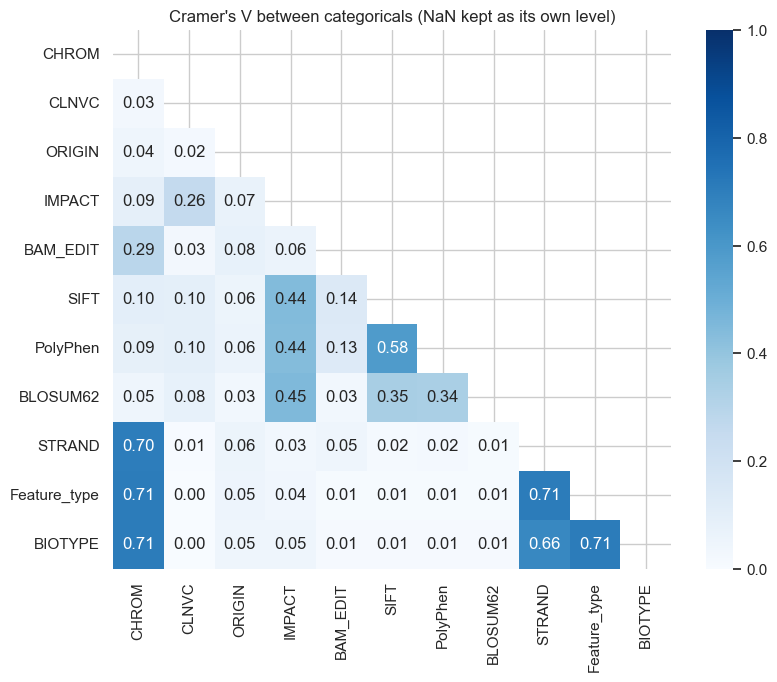

In [29]:
def cramers_v(x, y):
    t = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(t)[0]
    r, k = t.shape
    return np.sqrt(chi2 / (t.values.sum() * (min(r, k) - 1))) if min(r, k) > 1 else np.nan


CATV = ["CHROM", "CLNVC", "ORIGIN", "IMPACT", "BAM_EDIT", "SIFT", "PolyPhen", "BLOSUM62", "STRAND", "Feature_type", "BIOTYPE"]
cv = df[CATV].astype(str)
V = pd.DataFrame([[cramers_v(cv[a], cv[b]) for b in CATV] for a in CATV], index=CATV, columns=CATV)
plt.figure(figsize=(9, 7))
sns.heatmap(V, mask=np.triu(np.ones_like(V, dtype=bool)), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Cramer's V between categoricals (NaN kept as its own level)")
save("09_cramers_v")

**Findings**

- Redundant numerics: `CADD_RAW` vs. `CADD_PHRED` (Spearman 1.00), `cDNA` / `CDS` / `Protein_position` (r = 1.00), and the three allele-frequency sources (r = 0.81-0.85). Keep one of each group, or combine the AF sources (for example the max).
- Pearson and Spearman disagree for `LoFtool` vs. positions (0.34 vs. 0.09): a few very long genes (TTN) drive the Pearson value.
- Categorical vs. numeric: `CADD_PHRED` differs strongly across `PolyPhen` (eps2 = 0.51), `SIFT` (0.50) and `IMPACT` (0.38; HIGH vs. LOW rank-biserial -0.99). These all encode predicted deleteriousness, so they overlap. `BAM_EDIT` vs. `AF_EXAC` (r_rb = 0.43) is a pipeline artifact on a near-constant column.
- Cramer's V confirms the overlap of `SIFT` / `PolyPhen` / `BLOSUM62` (all driven by the shared missing level) and their link to `IMPACT`.

## 10. Feature-target relationships
Numeric features: the target is binary, so the main measure is **single-feature ROC AUC** (reported as |AUC - 0.5| with direction); it is rank-based, so robust to the heavy skew seen in Section 6, and directly readable as separability. Mutual information is added to catch non-monotonic shapes that AUC misses; binned-rate plots confirm the shape.

In [30]:
y = df["CLASS"]
rows = []
for c in NUM9 + ["STRAND"]:
    d = df[[c, "CLASS"]].dropna()
    auc = roc_auc_score(d["CLASS"], d[c])
    u, p = stats.mannwhitneyu(d.loc[d.CLASS == 1, c], d.loc[d.CLASS == 0, c])
    mi = mutual_info_classif(d[[c]], d["CLASS"], random_state=SEED)[0]
    rows.append({"feature": c, "auc": auc, "rank_biserial": 2 * auc - 1, "mi": mi, "p": p, "n": len(d)})
num_t = pd.DataFrame(rows)
num_t["p_bh"] = multipletests(num_t["p"], method="fdr_bh")[1]
num_t["abs_auc_dev"] = (num_t["auc"] - 0.5).abs()
num_t = num_t.sort_values("abs_auc_dev", ascending=False)
num_t.round(4)

,feature,auc,rank_biserial,mi,p,n,p_bh,abs_auc_dev
1,AF_EXAC,0.5510,0.1021,0.0497,0.0000,65188,0.0000,0.0510
5,CADD_RAW,0.4797,-0.0405,0.0067,0.0000,64096,0.0000,0.0203
4,CADD_PHRED,0.4798,-0.0404,0.0063,0.0000,64096,0.0000,0.0202
10,STRAND,0.4819,-0.0361,0.0085,0.0000,65174,0.0000,0.0181
0,AF_ESP,0.5170,0.0339,0.0399,0.0000,65188,0.0000,0.0170
8,Protein_position,0.5117,0.0234,0.0021,0.0000,55233,0.0001,0.0117
7,CDS_position,0.5117,0.0234,0.0032,0.0000,55233,0.0001,0.0117
6,cDNA_position,0.5077,0.0155,0.0011,0.0060,56304,0.0082,0.0077
2,AF_TGP,0.5058,0.0115,0.0460,0.0133,65188,0.0162,0.0058
9,BLOSUM62,0.4995,-0.0011,0.0004,0.8944,25593,0.9546,0.0005


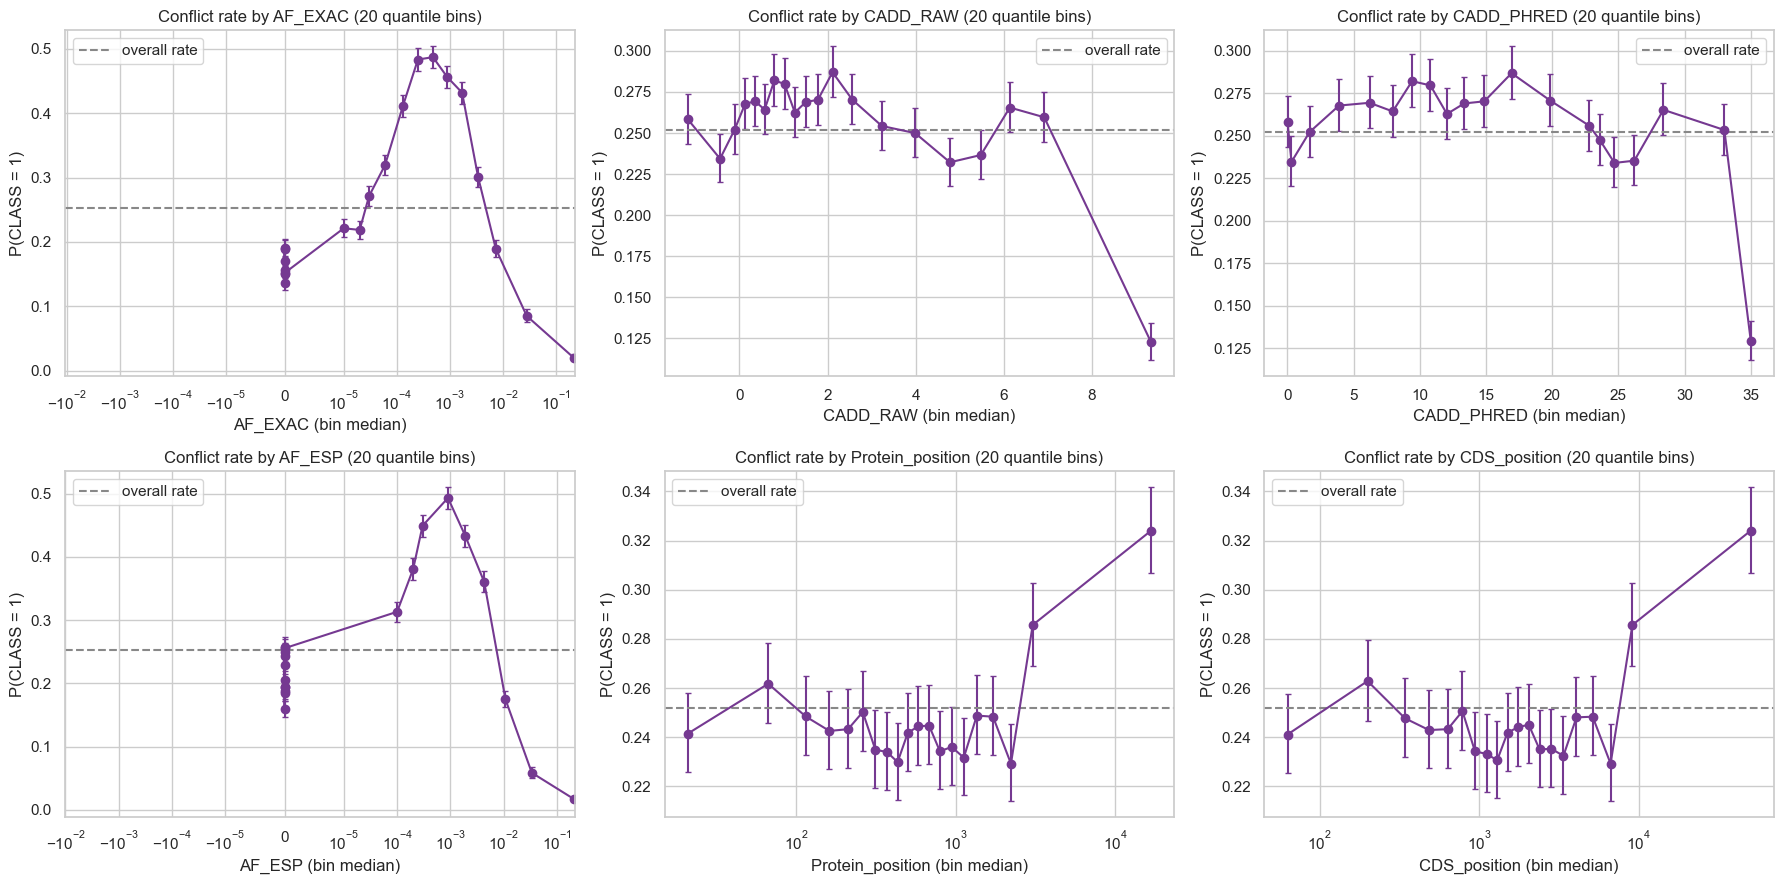

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
binned_feats = [c for c in num_t["feature"] if df[c].nunique() > 20][:6]
for ax, c in zip(axes.flat, binned_feats):
    d = df[[c, "CLASS"]].dropna()
    d["bin"] = pd.qcut(d[c].rank(method="first"), 20, labels=False)
    b = d.groupby("bin").agg(x=(c, "median"), rate=("CLASS", "mean"), n=("CLASS", "size"))
    ci = proportion_confint(b["rate"] * b["n"], b["n"], method="wilson")
    ax.errorbar(b["x"], b["rate"], yerr=[b["rate"] - ci[0], ci[1] - b["rate"]], fmt="o-", color="#753991", capsize=2)
    ax.axhline(y.mean(), ls="--", color="#888888", label="overall rate")
    ax.set(title=f"Conflict rate by {c} (20 quantile bins)", xlabel=f"{c} (bin median)", ylabel="P(CLASS = 1)")
    if c.startswith("AF_"):
        ax.set_xscale("symlog", linthresh=1e-5)
    elif c.endswith("_position"):
        ax.set_xscale("log")
    ax.legend()
plt.tight_layout()
save("10_numeric_binned_rate")

Categorical features: chi-square of independence with Cramer's V (BH-corrected), then the conflict rate per level with Wilson 95% intervals.

In [32]:
CAT10 = CATV + ["SYMBOL", "Consequence"]
rows = []
for c in CAT10:
    x = df[c].astype(str)
    t = pd.crosstab(x, y)
    chi2, p, dof, _ = stats.chi2_contingency(t)
    rows.append({"feature": c, "levels": t.shape[0], "cramers_v": cramers_v(x, y), "chi2": chi2, "dof": dof, "p": p})
cat_t = pd.DataFrame(rows)
cat_t["p_bh"] = multipletests(cat_t["p"], method="fdr_bh")[1]
cat_t = cat_t.sort_values("cramers_v", ascending=False)
cat_t.round(4)

,feature,levels,cramers_v,chi2,dof,p,p_bh
11,SYMBOL,2329,0.3101,6269.2092,2328,0.0000,0.0000
12,Consequence,48,0.1331,1155.5906,47,0.0000,0.0000
3,IMPACT,4,0.1165,884.6858,3,0.0000,0.0000
0,CHROM,24,0.0656,280.4109,23,0.0000,0.0000
2,ORIGIN,31,0.0507,167.5760,30,0.0000,0.0000
1,CLNVC,7,0.0398,103.2213,6,0.0000,0.0000
8,STRAND,3,0.0340,75.4588,2,0.0000,0.0000
7,BLOSUM62,7,0.0301,58.9063,6,0.0000,0.0000
5,SIFT,5,0.0212,29.2498,4,0.0000,0.0000
6,PolyPhen,5,0.0195,24.7530,4,0.0001,0.0001


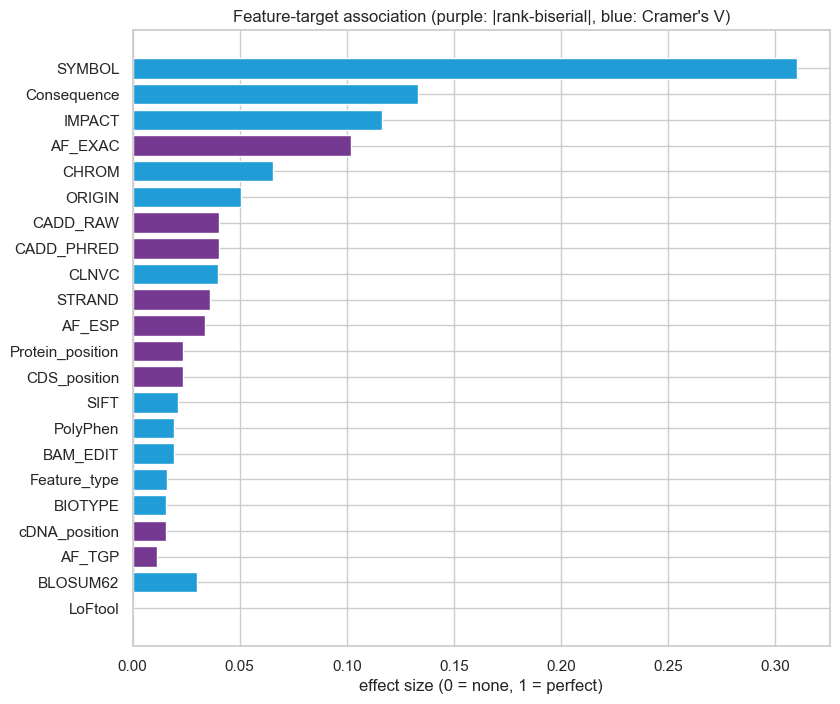

,feature,measure,value
11,SYMBOL,Cramer's V,0.310
12,Consequence,Cramer's V,0.133
3,IMPACT,Cramer's V,0.116
1,AF_EXAC,2*|AUC-0.5| (rank-biserial),0.102
0,CHROM,Cramer's V,0.066
2,ORIGIN,Cramer's V,0.051
5,CADD_RAW,2*|AUC-0.5| (rank-biserial),0.041
4,CADD_PHRED,2*|AUC-0.5| (rank-biserial),0.040
1,CLNVC,Cramer's V,0.040
10,STRAND,2*|AUC-0.5| (rank-biserial),0.036


In [33]:
rank = pd.concat([num_t.assign(measure="2*|AUC-0.5| (rank-biserial)", value=2 * num_t["abs_auc_dev"])[["feature", "measure", "value"]],
                  cat_t.assign(measure="Cramer's V", value=cat_t["cramers_v"])[["feature", "measure", "value"]]])
rank = rank.sort_values("value")
plt.figure(figsize=(9, 8))
colors = rank["measure"].map({"Cramer's V": "#209dd7"}).fillna("#753991")
plt.barh(rank["feature"], rank["value"], color=colors)
plt.title("Feature-target association (purple: |rank-biserial|, blue: Cramer's V)")
plt.xlabel("effect size (0 = none, 1 = perfect)")
save("10_target_association_rank")
rank.sort_values("value", ascending=False).round(3)

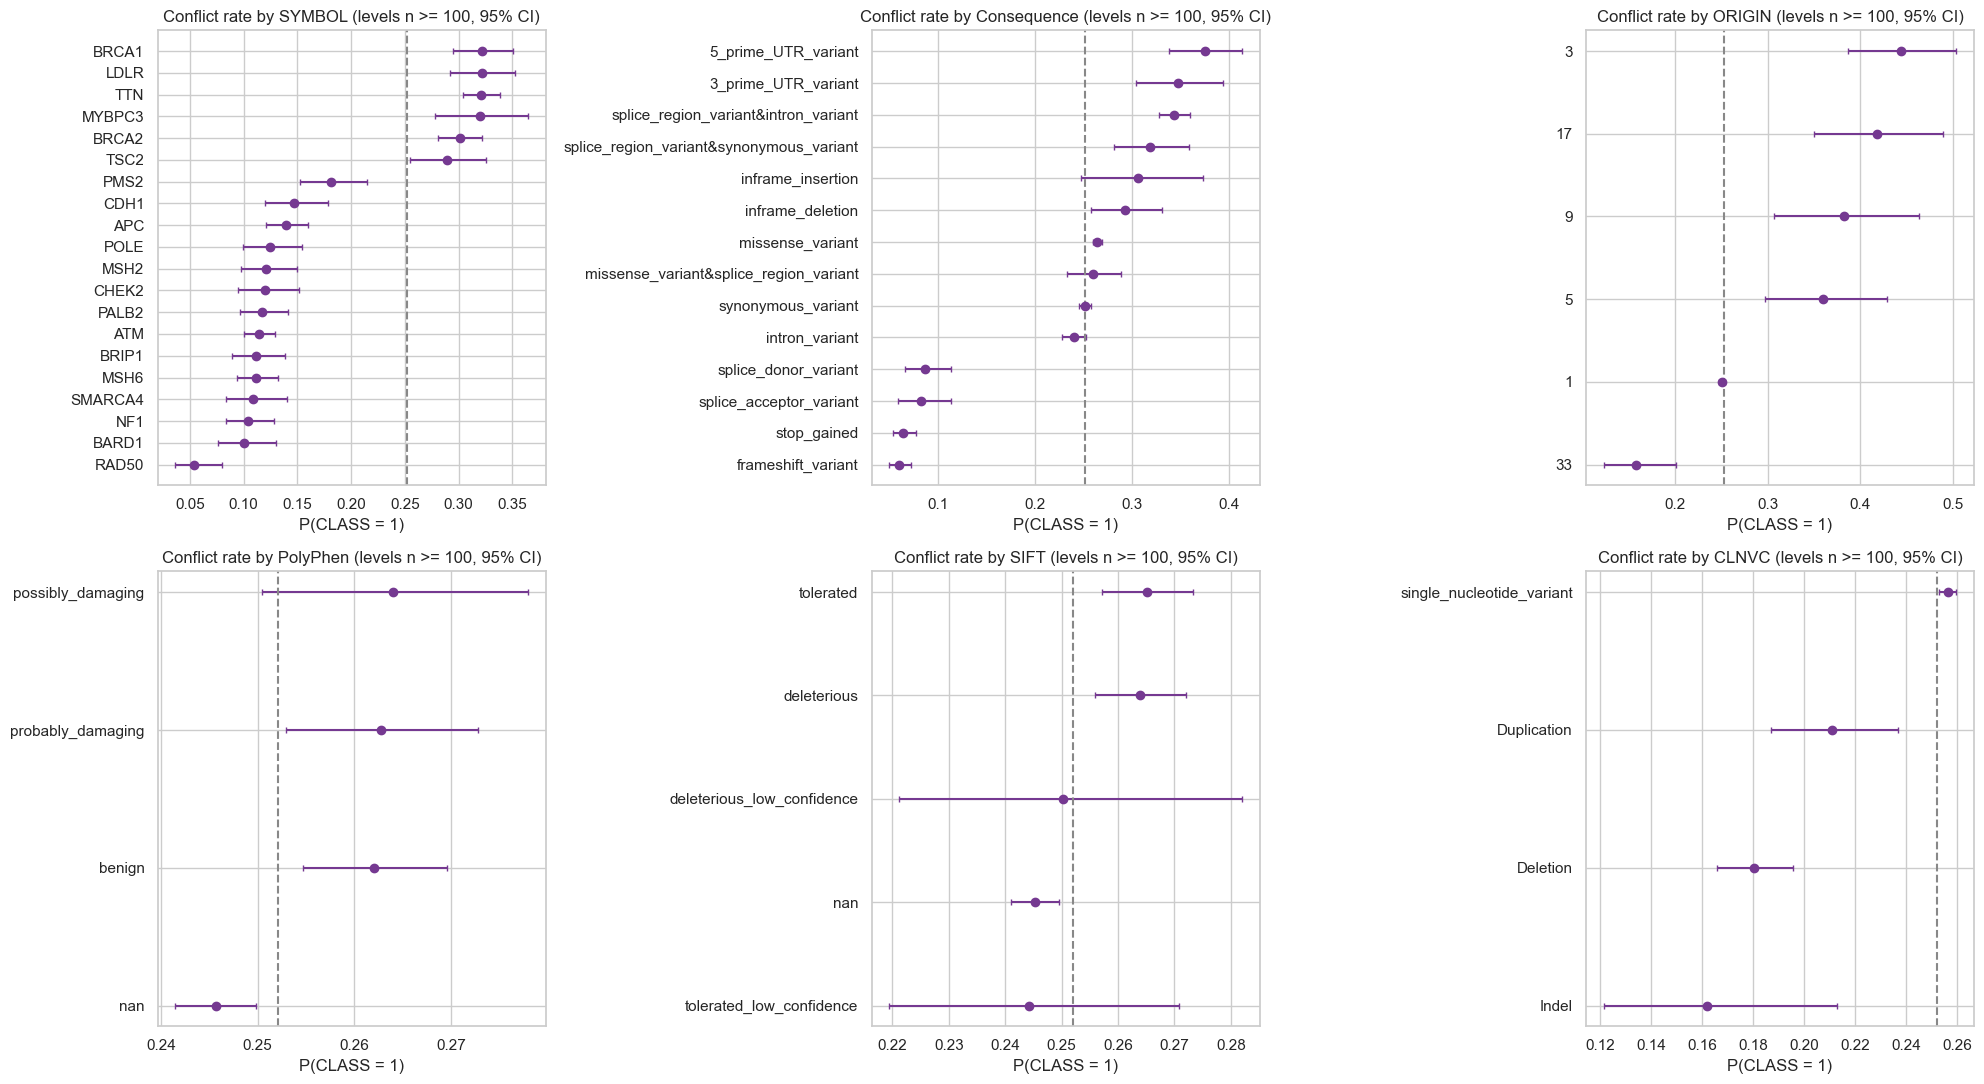

In [34]:
def rate_plot(ax, c, min_n=100, top=20):
    g = df.groupby(df[c].astype(str))["CLASS"].agg(["mean", "size"])
    g = g[g["size"] >= min_n].sort_values("size", ascending=False).head(top).sort_values("mean")
    lo, hi = proportion_confint(g["mean"] * g["size"], g["size"], method="wilson")
    ax.errorbar(g["mean"], g.index, xerr=[g["mean"] - lo, hi - g["mean"]], fmt="o", color="#753991", capsize=2)
    ax.axvline(y.mean(), ls="--", color="#888888")
    ax.set(title=f"Conflict rate by {c} (levels n >= {min_n}, 95% CI)", xlabel="P(CLASS = 1)")


fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for ax, c in zip(axes.flat, ["SYMBOL", "Consequence", "ORIGIN", "PolyPhen", "SIFT", "CLNVC"]):
    rate_plot(ax, c)
plt.tight_layout()
save("10_categorical_rate")

**Simpson's paradox check**: AUC of the top numeric features within each `IMPACT` level and each variant type, compared with the pooled AUC.

In [35]:
top_num = num_t["feature"].head(4).tolist()
rows = []
for strat in ["IMPACT", "CLNVC"]:
    for lvl, g in df.groupby(strat):
        for c in top_num:
            d = g[[c, "CLASS"]].dropna()
            if len(d) >= 200 and d["CLASS"].nunique() == 2:
                rows.append({"stratum": f"{strat}={lvl}", "feature": c, "n": len(d), "auc": roc_auc_score(d["CLASS"], d[c])})
simp = pd.DataFrame(rows).pivot(index="stratum", columns="feature", values="auc")
simp.loc["POOLED"] = num_t.set_index("feature").loc[top_num, "auc"]
simp.round(3)

feature,AF_EXAC,CADD_PHRED,CADD_RAW,STRAND
stratum,,,,
CLNVC=Deletion,0.585,0.326,0.326,0.473
CLNVC=Duplication,0.505,0.316,0.316,0.449
CLNVC=Indel,0.500,NaN,NaN,0.440
CLNVC=single_nucleotide_variant,0.544,0.488,0.488,0.483
IMPACT=HIGH,0.637,0.438,0.438,0.435
IMPACT=LOW,0.451,0.523,0.523,0.479
IMPACT=MODERATE,0.599,0.500,0.500,0.482
IMPACT=MODIFIER,0.388,0.544,0.545,0.504
POOLED,0.551,0.480,0.480,0.482


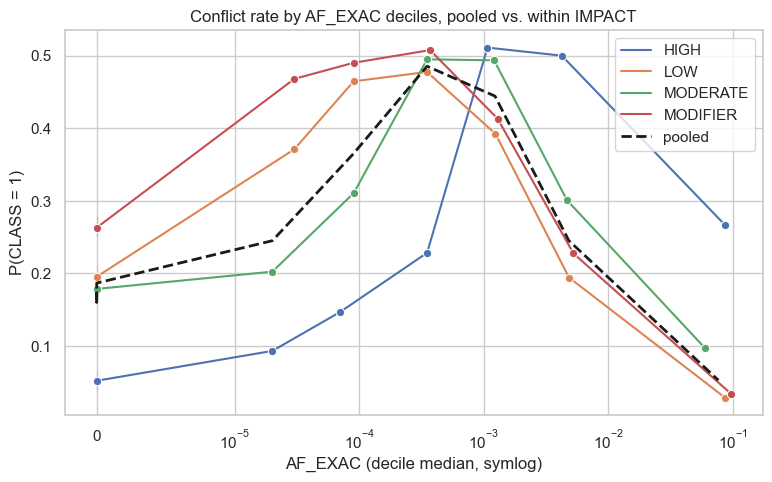

In [36]:
c = top_num[0]
d = df[[c, "CLASS", "IMPACT"]].dropna()
d["bin"] = pd.qcut(d[c].rank(method="first"), 10, labels=False)
strat = d.groupby(["IMPACT", "bin"]).agg(x=(c, "median"), rate=("CLASS", "mean")).reset_index()
pooled = d.groupby("bin").agg(x=(c, "median"), rate=("CLASS", "mean"))
plt.figure(figsize=(9, 5))
sns.lineplot(data=strat, x="x", y="rate", hue="IMPACT", marker="o")
plt.plot(pooled["x"], pooled["rate"], "k--", lw=2, label="pooled")
plt.xscale("symlog", linthresh=1e-5)
plt.title(f"Conflict rate by {c} deciles, pooled vs. within IMPACT")
plt.xlabel(f"{c} (decile median, symlog)")
plt.ylabel("P(CLASS = 1)")
plt.legend()
save("10_simpson_check")

**Findings**

- **Allele frequency is the strongest numeric signal, and it is non-monotonic.** The ExAC frequency has AUC only 0.55, but the highest mutual information (0.050). The binned plot shows an inverted U: the conflict rate is ~15% at AF = 0, rises to ~49% around AF 1e-3, and falls to ~2% for common variants (AF > 0.1). Rare-but-seen variants are where labs disagree on benign vs. pathogenic. Linear models need binned or spline AF; trees capture it directly.
- `CADD` and `LoFtool` barely separate the classes (|r_rb| <= 0.04). Very high CADD (> 33) drops the rate to ~13%: clearly damaging variants get agreement.
- **Categoricals:** `SYMBOL` has the largest Cramer's V (0.31), partly inflated by 2,328 levels. Among genes with >= 20 variants, conflict rates range 0.00-0.91 (for example TTN / BRCA1 / LDLR ~32% vs. ATM / NF1 / RAD50 5-12%). `Consequence` (V = 0.13): frameshift / stop-gained / splice donor-acceptor ~6-9% (clear loss of function, so consensus pathogenic) vs. UTR and splice-region ~33-37%. `IMPACT` (0.12) follows the same pattern. `SIFT` / `PolyPhen` add almost nothing (V ~0.02).
- **Simpson check:** the AF effect changes direction across `IMPACT`. The within-stratum AUC is 0.64 for HIGH and 0.60 for MODERATE vs. 0.45 for LOW and 0.39 for MODIFIER (pooled 0.55). The stratified plot shows why: the peak of the inverted U sits at AF ~1e-3 to 1e-2 for HIGH-impact variants but at ~2e-5 to 1e-4 for MODIFIER / LOW. The CADD effect is stronger within deletions / duplications (AUC 0.32-0.33) than pooled (0.48). **AF x IMPACT and CADD x variant-type interactions matter**, which favors tree ensembles.

## 11. Leakage verdict
ClinVar-derived columns are produced by the same submissions that define the target. A variant can only be *conflicting* if at least two labs submitted it, so anything that counts submissions or submitted conditions is a proxy. These probes are for leakage only, not features.

In [37]:
probe = pd.DataFrame({
    "n_conditions_CLNDN": df["CLNDN"].fillna("").str.count(r"\|") + 1,
    "CLNDN_has_not_specified": df["CLNDN"].str.contains("not_specified", na=False).astype(int),
    "CLNVI_present": df["CLNVI"].notna().astype(int),
    "CLNSIGINCL_present": df["CLNSIGINCL"].notna().astype(int),
    "n_ids_CLNDISDB": df["CLNDISDB"].fillna("").str.count(",") + 1,
})
leak = pd.DataFrame({c: {"auc": roc_auc_score(y, probe[c]),
                         "rate_at_min": y[probe[c] == probe[c].min()].mean(),
                         "rate_above_min": y[probe[c] > probe[c].min()].mean()}
                     for c in probe}).T
leak["abs_auc_dev"] = (leak["auc"] - 0.5).abs()
leak.sort_values("abs_auc_dev", ascending=False).round(3)

,auc,rate_at_min,rate_above_min,abs_auc_dev
CLNVI_present,0.579,0.200,0.322,0.079
n_conditions_CLNDN,0.568,0.218,0.257,0.068
CLNDN_has_not_specified,0.554,0.184,0.281,0.054
n_ids_CLNDISDB,0.521,0.258,0.251,0.021
CLNSIGINCL_present,0.501,0.252,0.413,0.001


In [38]:
g = df.groupby("SYMBOL")["CLASS"].agg(["mean", "size"])
print(f"genes with >= 20 variants: {(g['size'] >= 20).sum()}, their conflict rate ranges "
      f"{g.loc[g['size'] >= 20, 'mean'].min():.2f} - {g.loc[g['size'] >= 20, 'mean'].max():.2f}")
tr, te = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["CLASS"])
print(f"random 80/20 split: {te['SYMBOL'].isin(tr['SYMBOL']).mean():.1%} of test rows have their gene in train")

genes with >= 20 variants: 582, their conflict rate ranges 0.00 - 0.91
random 80/20 split: 99.2% of test rows have their gene in train


**Findings**

| Suspect | Evidence | Verdict |
|---|---|---|
| `CLNVI` (external variant IDs) | AUC 0.58 as present / absent; conflict 32% vs. 20% | **Check with user.** It is written by ClinVar from submissions, and whether it exists at prediction time depends on the use case. Exclude for a "new variant" model. |
| `CLNDN`, `CLNDISDB` (submitted conditions) | Number of listed conditions AUC 0.57. A conflict needs >= 2 submissions, and more submitters list more conditions | **Drop** for prediction on new variants (a proxy for submission count). Keep only if the model scores variants that already have submissions. |
| `CLNSIGINCL`, `CLNDNINCL`, `CLNDISDBINCL` | 99.7% empty; submission-derived | **Drop** |
| `SYMBOL` (gene) | Conflict rate 0-0.91 by gene; a random split puts 99.2% of test rows in genes seen in training | **Keep** as a feature (gene is known up front), but evaluate with a group split so gene-level memorization is not mistaken for skill. |
| Allele frequencies, VEP, CADD, SIFT, PolyPhen, LoFtool | Computed from sequence and population data, independent of ClinVar submissions; max single-feature AUC 0.55 | **Keep** |

No feature reaches AUC > 0.95, and there are no conflicting duplicates.

## 12. Split recommendations
The data comes as a single file, so this section recommends how to split it rather than checking an existing split.

**Findings**

- **No time column**, so an out-of-time holdout is impossible. If ClinVar submission dates can be joined, a temporal holdout is the best mimic of production.
- **Group split by gene** (`StratifiedGroupKFold` on `SYMBOL`, stratified by `CLASS`). A random split leaves 99.2% of test rows in genes seen in training and will overstate performance for variants in new or rare genes. If the model will only score variants in genes already in ClinVar, also report a random stratified split, since the two answer different questions.
- Stratify by `CLASS` (25% positive). Watch that TTN (4% of rows) and the top-10 genes (20%) don't concentrate in one fold.
- Report metrics per `CLNVC` and `IMPACT` group: indels and HIGH-impact variants are small groups with different conflict mechanics (Section 10).
- Hold out a final test set of ~20% of genes, untouched until model selection is done.

## Summary

In [39]:
pd.DataFrame(cleaning_log)

,step,detail,rows_affected
0,parse,"cDNA_position: text to number, first coordinat...",2276
1,parse,"CDS_position: text to number, first coordinate...",2201
2,parse,"Protein_position: text to number, first coordi...",1206
3,parse,"ORIGIN, CHROM: cast to string (codes, not quan...",0


**Findings**

**Key findings**
1. 65,188 unique variants, 25.2% conflicting; one row per variant, but variants cluster in 2,328 genes (TTN alone 4%), so validation must group by gene.
2. Allele frequency is the main signal, and it is non-monotonic: conflicts peak (~49%) for rare-but-observed variants (AF ~1e-3) and are low for unseen (15%) and common (2%) variants. The peak location shifts with `IMPACT` (a Simpson-type reversal of the pooled AUC direction).
3. Clear loss-of-function consequences (frameshift, stop-gained, splice donor/acceptor) rarely conflict (6-9%); UTR and splice-region variants often do (33-37%).
4. Gene identity carries strong signal (conflict rate 0-0.91 across genes with >= 20 variants); a random split would leak it.
5. ClinVar-derived text fields (`CLNDN`, `CLNDISDB`, `CLNVI`) proxy the number of submissions and should be excluded for a new-variant model.

**Cleaning log**: see the table above (3 position columns parsed to numbers; `ORIGIN` / `CHROM` cast to categorical). No rows removed, no values set to missing, no outliers removed.

**Next steps for modeling**
- Drop: 9 near-empty columns, `Feature_type`, `BIOTYPE`, `BAM_EDIT`, identifiers, `CADD_RAW`, two of the three position columns, and the ClinVar-derived fields (pending the user's decision on `CLNVI`).
- Transform: `log10(AF + 1e-5)` (or keep raw AF for trees), `log1p` for position; group rare `ORIGIN` / `CLNVC` / `CHROM` levels.
- Manual treatment: `SYMBOL` (target encoding inside folds), `Consequence` / `MC` (split multi-valued terms), `EXON` / `INTRON` (number / total), `REF` / `ALT` length, `Amino_acids`, `Codons`.
- Model: gradient-boosted trees (non-monotonic AF, interactions, structural NaNs), `StratifiedGroupKFold` by gene, metrics PR-AUC plus ROC-AUC, per-`IMPACT` breakdown.